# Temporal Graph Neural Network for Intrusion Detection using CICIDS2017

This notebook implements a research-grade end-to-end pipeline for dynamic graph-based intrusion detection:

1. Load and merge CICIDS2017 CSV files
2. Clean and preprocess (NaN/Inf removal, encoding, normalization, binary labels)
3. Construct temporal graph snapshots for edge classification
4. Train a temporal GNN (GAT + LSTM) with early stopping and LR scheduler
5. Compare with baselines (Random Forest, Logistic Regression, MLP)
6. Evaluate with full metrics and publication-ready plots
7. Add explainability (GAT attention + SHAP/permutation importance)
8. Save trained model and evaluation artifacts

Note: Some CICIDS2017 releases do not include Source IP / Destination IP / Timestamp columns. This notebook handles both cases and documents the fallback graph construction strategy if IP/time columns are unavailable.

In [2]:
import os
import json
import warnings
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch_geometric.data import Data
from torch_geometric.nn import GATConv

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')

NOTEBOOK_START = time.perf_counter()

def format_seconds(sec: float) -> str:
    sec = float(max(0.0, sec))
    if sec < 60:
        return f"{sec:.1f}s"
    if sec < 3600:
        return f"{sec/60:.1f}m"
    return f"{sec/3600:.2f}h"

def log_step(msg: str):
    elapsed = time.perf_counter() - NOTEBOOK_START
    print(f"[{format_seconds(elapsed):>8}] {msg}", flush=True)

def progress_table(stage: str, current: int, total: int, start_time: float, extra: str = "") -> None:
    total = max(int(total), 1)
    current = min(max(int(current), 0), total)
    pct = 100.0 * current / total
    bar_w = 24
    filled = int(bar_w * current / total)
    bar = "#" * filled + "-" * (bar_w - filled)
    elapsed = time.perf_counter() - start_time
    eta = (elapsed / current * (total - current)) if current > 0 else float('nan')
    eta_txt = format_seconds(eta) if np.isfinite(eta) else "--"
    line = (
        f"{stage:<14} [{bar}] {current:>4}/{total:<4} {pct:5.1f}% "
        f"| elapsed={format_seconds(elapsed)} | ETA={eta_txt}"
    )
    if extra:
        line += f" | {extra}"
    print("\r" + line, end="", flush=True)
    if current >= total:
        print()

CONFIG = {
    'seed': 42,
    'data_dir': Path('../data'),
    # Larger window dramatically reduces snapshot count and training time.
    'window_size': '300s',
    # Lower row cap for faster iteration; set higher for final full run.
    'max_rows_per_file': 200000,
    'num_epochs': 40,
    'lr': 8e-4,
    'weight_decay': 1e-4,
    'dropout': 0.2,
    'hidden_dim': 64,
    'lstm_hidden': 64,
    'patience': 8,
    'batch_stream_size': 5,
    'snapshot_chunk_size': 4,
    # Split strategy controls
    'split_mode': 'per_day_temporal',
    'split_train': 0.70,
    'split_val': 0.15,
    'split_test': 0.15,
    # Optimization stability controls
    'grad_clip_norm': 1.0,
    'focal_gamma': 1.5,
    # Speed controls
    'max_edges_per_snapshot': 3000,
    'max_train_snapshots': 500,
    'max_val_snapshots': 150,
    'max_test_snapshots': 150,
    # Threshold tuning controls
    'threshold_far_target': 0.30,
    'threshold_min': 0.05,
    'threshold_max': 0.95,
    'threshold_step': 0.01,
    'chunk_log_interval': 1,
    'verbose': True,
    'compact_progress': True,
}

def set_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG['seed'])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
log_step(f'Using device: {device}')
if torch.cuda.is_available():
    log_step(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.cuda.empty_cache()
else:
    log_step('Warning: CUDA is not available. Training will run on CPU.')

[    0.1s] Using device: cuda
[    0.1s] GPU: NVIDIA GeForce RTX 3050


In [3]:
#%pip install shap>=0.41.0 lime>=0.2.0.1 scikit-learn

In [4]:
# XAI integration: SHAP (Kernel) and LIME demo using explainability.xia
print('Setting up XAI demo: importing helpers...')
import numpy as np
import torch
from pathlib import Path
try:
    from explainability.xia import numpy_predict_fn_factory, explain_with_shap_kernel, explain_with_lime
    _xia_available = True
except Exception as _e:
    print('Warning: explainability.xia could not be imported:', _e)
    _xia_available = False

# Try to load a trained model from models/ if available, otherwise use a tiny dummy model
def _load_model_or_dummy(path: str, num_features: int = 10, num_classes: int = 2):
    p = Path(path)
    if p.exists():
        try:
            state = torch.load(str(p), map_location='cpu')
            # If state is a state_dict, user should adapt loader to their class; try a common pattern
            if isinstance(state, dict) and ('state_dict' in state or any(k.startswith('module.') for k in state.keys())):
                # User may need to provide model class; fall back to tiny model
                print('Found checkpoint dict but no model class; falling back to dummy model.')
            else:
                print('Loaded checkpoint object (unknown type); using dummy model for XAI demo.')
        except Exception as e:
            print('Failed to load checkpoint:', e)
    # Dummy model: small MLP that returns logits
    m = torch.nn.Sequential(torch.nn.Linear(num_features, 32), torch.nn.ReLU(), torch.nn.Linear(32, num_classes))
    return m

# Prepare tiny dataset for demo (replace with real features/snapshots)
X_demo = np.random.randn(100, 10).astype(np.float32)
background = X_demo[np.random.choice(len(X_demo), 20, replace=False)]
samples = X_demo[:5]
instance = X_demo[0]

model_path = Path('..') / 'models' / 'temporal_gnn_upgraded_rank1.pt'
model = _load_model_or_dummy(model_path, num_features=10, num_classes=2)

if _xia_available:
    predict_fn = numpy_predict_fn_factory(model, device='cpu')
    print('Running SHAP KernelExplainer (nsamples=30) — this may take a moment...')
    try:
        shap_vals = explain_with_shap_kernel(predict_fn, background, samples, nsamples=30)
        print('SHAP returned', type(shap_vals), 'with', len(shap_vals), 'arrays (one per class).')
    except Exception as e:
        print('SHAP run failed:', e)

    print('Running LIME for a single instance...')
    try:
        lime_exp = explain_with_lime(predict_fn, background, instance)
        print('LIME explanation (top features):', lime_exp.as_list())
    except Exception as e:
        print('LIME run failed:', e)
else:
    print('XAI helpers not available — install requirements-xia.txt and re-run this cell.')


Setting up XAI demo: importing helpers...
Loaded checkpoint object (unknown type); using dummy model for XAI demo.
XAI helpers not available — install requirements-xia.txt and re-run this cell.


In [5]:
# Required project structure
for folder in ['data', 'preprocessing', 'graph_builder', 'models', 'training', 'evaluation', 'utils', 'evaluation/plots']:
    Path('..', folder).mkdir(parents=True, exist_ok=True)

csv_files = sorted(CONFIG['data_dir'].glob('*.csv'))
print(f'Found {len(csv_files)} CSV files')
for p in csv_files:
    print(' -', p.name)

assert len(csv_files) > 0, 'No CSV files found in data directory.'

Found 8 CSV files
 - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 - Friday-WorkingHours-Morning.pcap_ISCX.csv
 - Monday-WorkingHours.pcap_ISCX.csv
 - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 - Tuesday-WorkingHours.pcap_ISCX.csv
 - Wednesday-workingHours.pcap_ISCX.csv


In [6]:
def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = [str(c).strip() for c in df.columns]
    # Handle accidental duplicate columns by suffixing in a stable way
    seen = {}
    new_cols = []
    for c in df.columns:
        if c not in seen:
            seen[c] = 0
            new_cols.append(c)
        else:
            seen[c] += 1
            new_cols.append(f'{c}__dup{seen[c]}')
    df.columns = new_cols
    return df

def load_and_merge_cicids(data_dir: Path, max_rows_per_file=None) -> pd.DataFrame:
    # Keep only columns needed by this pipeline to reduce memory usage.
    required_cols = {
        'Label',
        'Flow Duration',
        'Destination Port',
        'Total Fwd Packets',
        'Total Backward Packets',
        'Total Length of Fwd Packets',
        'Total Length of Bwd Packets',
        'Flow Bytes/s',
        'Flow Packets/s',
        'Source IP', 'Src IP', 'source_ip',
        'Destination IP', 'Dst IP', 'destination_ip',
        'Flow ID', 'Flow_ID',
        'Timestamp', 'Flow Start', 'Date',
    }

    csv_paths = sorted(data_dir.glob('*.csv'))
    log_step(f'Loading {len(csv_paths)} CSV files from {data_dir} (max_rows_per_file={max_rows_per_file})')

    frames = []
    total_rows = 0
    t_all = time.perf_counter()

    for i, csv_path in enumerate(csv_paths, start=1):
        t_file = time.perf_counter()

        def _use_col(c):
            return str(c).strip() in required_cols

        tmp = pd.read_csv(
            csv_path,
            low_memory=True,
            nrows=max_rows_per_file,
            usecols=_use_col,
        )
        tmp = standardize_columns(tmp)
        tmp['day_file'] = csv_path.name

        # Downcast numeric columns aggressively for memory efficiency.
        for col in tmp.columns:
            if col in {'day_file', 'Label', 'Source IP', 'Src IP', 'source_ip', 'Destination IP', 'Dst IP', 'destination_ip', 'Flow ID', 'Flow_ID', 'Timestamp', 'Flow Start', 'Date'}:
                continue
            tmp[col] = pd.to_numeric(tmp[col], errors='coerce', downcast='float')

        frames.append(tmp)
        total_rows += len(tmp)
        log_step(
            f"[{i}/{len(csv_paths)}] {csv_path.name}: rows={len(tmp):,}, cols={len(tmp.columns)}, "
            f"time={format_seconds(time.perf_counter() - t_file)}"
        )

    merged = pd.concat(frames, axis=0, ignore_index=True)
    log_step(
        f"Merged dataframe shape={merged.shape} (total_rows_read={total_rows:,}) in "
        f"{format_seconds(time.perf_counter() - t_all)}"
    )
    return merged

def locate_column(df: pd.DataFrame, candidates: List[str]) -> str:
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return ''

def add_binary_label(df: pd.DataFrame) -> pd.DataFrame:
    t0 = time.perf_counter()
    label_col = locate_column(df, ['Label'])
    if not label_col:
        raise ValueError('Label column was not found.')
    df[label_col] = df[label_col].astype(str).str.strip()
    df['binary_label'] = np.where(df[label_col].str.upper() == 'BENIGN', 0, 1).astype(np.int8)
    log_step(f"Binary labels created from '{label_col}' in {format_seconds(time.perf_counter() - t0)}")
    return df

def clean_dataset(df: pd.DataFrame) -> pd.DataFrame:
    t0 = time.perf_counter()
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
    before = len(df)
    df = df.dropna(axis=0).reset_index(drop=True)
    after = len(df)
    log_step(
        f"Clean step: removed {before - after:,} rows containing NaN/Inf; "
        f"remaining={after:,}; time={format_seconds(time.perf_counter() - t0)}"
    )
    return df

def prepare_time_and_endpoints(df: pd.DataFrame) -> pd.DataFrame:
    t0 = time.perf_counter()
    src_col = locate_column(df, ['Source IP', 'Src IP', 'source_ip'])
    dst_col = locate_column(df, ['Destination IP', 'Dst IP', 'destination_ip'])

    # If IP columns are not available, try Flow ID parsing.
    if (not src_col or not dst_col):
        flow_id_col = locate_column(df, ['Flow ID', 'Flow_ID'])
        if flow_id_col:
            parts = df[flow_id_col].astype(str).str.split('-', expand=True)
            if parts.shape[1] >= 2:
                df['Source IP'] = parts[0]
                df['Destination IP'] = parts[1]
                src_col, dst_col = 'Source IP', 'Destination IP'
                log_step('Endpoint fallback: extracted Source/Destination IP from Flow ID.')

    # Fallback for CICIDS variants without IP fields.
    if (not src_col or not dst_col):
        dport_col = locate_column(df, ['Destination Port'])
        if not dport_col:
            raise ValueError('Cannot construct endpoints: Destination Port and IP columns are missing.')
        synthetic_src = pd.util.hash_pandas_object(df[[dport_col]].astype(str), index=False) % 5000
        df['Source IP'] = 'SRC_' + synthetic_src.astype(str)
        df['Destination IP'] = 'DSTPORT_' + df[dport_col].astype(str)
        src_col, dst_col = 'Source IP', 'Destination IP'
        log_step('Endpoint fallback: generated synthetic Source/Destination endpoints.')

    ts_col = locate_column(df, ['Timestamp', 'Flow Start', 'Date'])
    if ts_col:
        ts = pd.to_datetime(df[ts_col], errors='coerce')
        log_step(f"Using time column '{ts_col}'")
    else:
        dur_col = locate_column(df, ['Flow Duration'])
        if not dur_col:
            raise ValueError('No Timestamp or Flow Duration column found to build temporal snapshots.')
        # CICIDS flow duration is typically in microseconds.
        duration_us = pd.to_numeric(df[dur_col], errors='coerce').fillna(0).clip(lower=0)
        ts = pd.Timestamp('2017-01-01') + pd.to_timedelta(duration_us.cumsum(), unit='us')
        log_step('Time fallback: built synthetic timeline from cumulative Flow Duration.')

    df['event_time'] = ts
    df = df.dropna(subset=['event_time']).reset_index(drop=True)
    df['Source IP'] = df[src_col].astype(str)
    df['Destination IP'] = df[dst_col].astype(str)
    log_step(f"Prepared endpoints and event_time in {format_seconds(time.perf_counter() - t0)}")
    return df

In [7]:
EDGE_FEATURE_CANDIDATES = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Flow Bytes/s',
    'Flow Packets/s',
]

t_stage = time.perf_counter()
log_step('Stage: load_and_merge_cicids')
raw_df = load_and_merge_cicids(CONFIG['data_dir'], CONFIG['max_rows_per_file'])

log_step('Stage: add_binary_label')
raw_df = add_binary_label(raw_df)

log_step('Stage: clean_dataset')
raw_df = clean_dataset(raw_df)

log_step('Stage: prepare_time_and_endpoints')
raw_df = prepare_time_and_endpoints(raw_df)

edge_feature_cols = []
for c in EDGE_FEATURE_CANDIDATES:
    found = locate_column(raw_df, [c])
    if not found:
        raise ValueError(f'Missing required edge feature column: {c}')
    edge_feature_cols.append(found)

log_step(f'Edge features resolved: {edge_feature_cols}')
log_step(
    f"Data ready: rows={len(raw_df):,}, attack_ratio={raw_df['binary_label'].mean():.4f}, "
    f"time={format_seconds(time.perf_counter() - t_stage)}"
)
print(raw_df[['day_file', 'binary_label']].head())

[    0.5s] Stage: load_and_merge_cicids
[    0.5s] Loading 8 CSV files from ..\data (max_rows_per_file=200000)
[    1.4s] [1/8] Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: rows=200,000, cols=10, time=0.9s
[    1.8s] [2/8] Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: rows=200,000, cols=10, time=0.4s
[    2.2s] [3/8] Friday-WorkingHours-Morning.pcap_ISCX.csv: rows=191,033, cols=10, time=0.4s
[    2.8s] [4/8] Monday-WorkingHours.pcap_ISCX.csv: rows=200,000, cols=10, time=0.6s
[    3.3s] [5/8] Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: rows=200,000, cols=10, time=0.4s
[    3.7s] [6/8] Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: rows=170,366, cols=10, time=0.4s
[    4.2s] [7/8] Tuesday-WorkingHours.pcap_ISCX.csv: rows=200,000, cols=10, time=0.5s
[    4.7s] [8/8] Wednesday-workingHours.pcap_ISCX.csv: rows=200,000, cols=10, time=0.5s
[    4.7s] Merged dataframe shape=(1561399, 10) (total_rows_read=1,561,399) in 4.3s
[    4.7s] Stage: add_binary_lab

,count,mean,std,min,25%,50%,75%,max
Flow Duration,1559907.0,1.654929e+07,3.496391e+07,-12.0,163.000000,56725.000000,5.501628e+06,1.200000e+08
Total Fwd Packets,1559907.0,1.249628e+01,1.000917e+03,1.0,2.000000,2.000000,6.000000e+00,2.197590e+05
Total Backward Packets,1559907.0,1.438918e+01,1.331877e+03,0.0,1.000000,2.000000,5.000000e+00,2.919220e+05
Total Length of Fwd Packets,1559907.0,6.556161e+02,1.286059e+04,0.0,12.000000,56.000000,3.380000e+02,1.290000e+07
Total Length of Bwd Packets,1559907.0,2.470425e+04,3.018367e+06,0.0,6.000000,117.000000,1.779000e+03,6.554530e+08
Flow Bytes/s,1559907.0,1.602086e+06,2.715821e+07,-261000000.0,115.517042,4098.369110,1.360618e+05,2.071000e+09
Flow Packets/s,1559907.0,7.106088e+04,2.573325e+05,-2000000.0,1.738136,67.804743,2.173913e+04,4.000000e+06


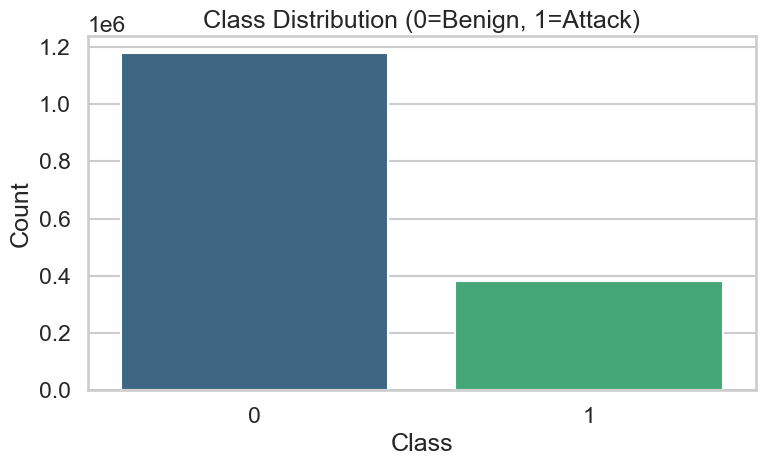

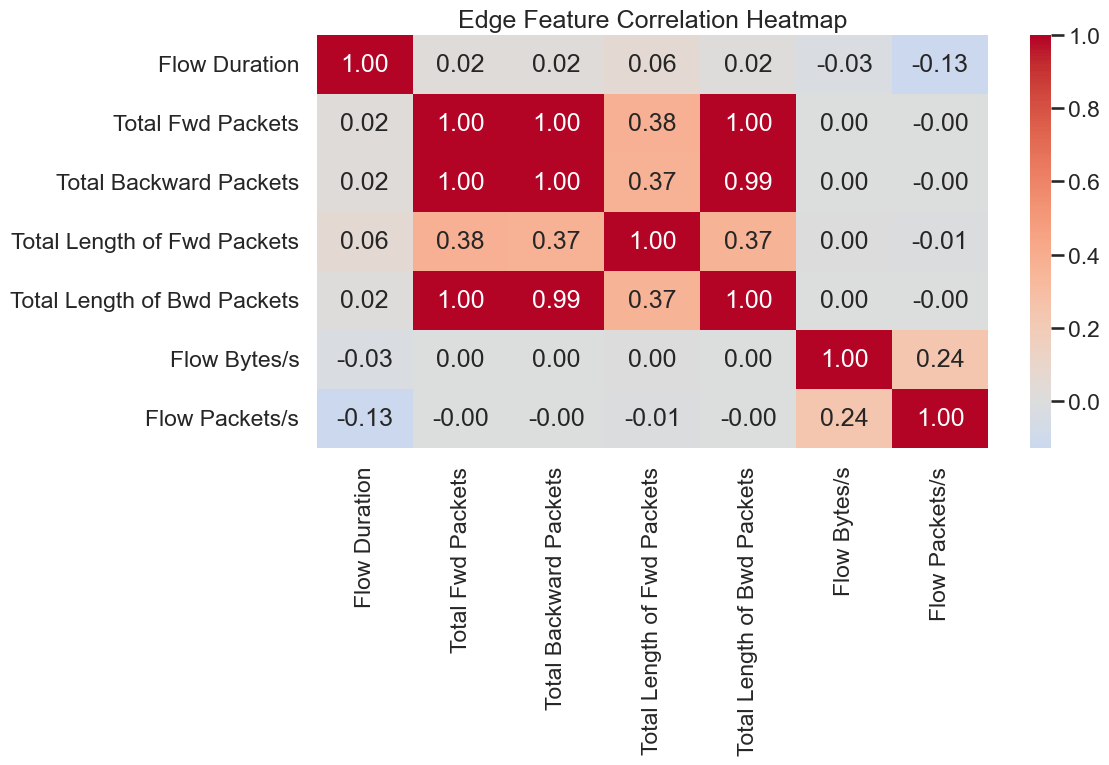

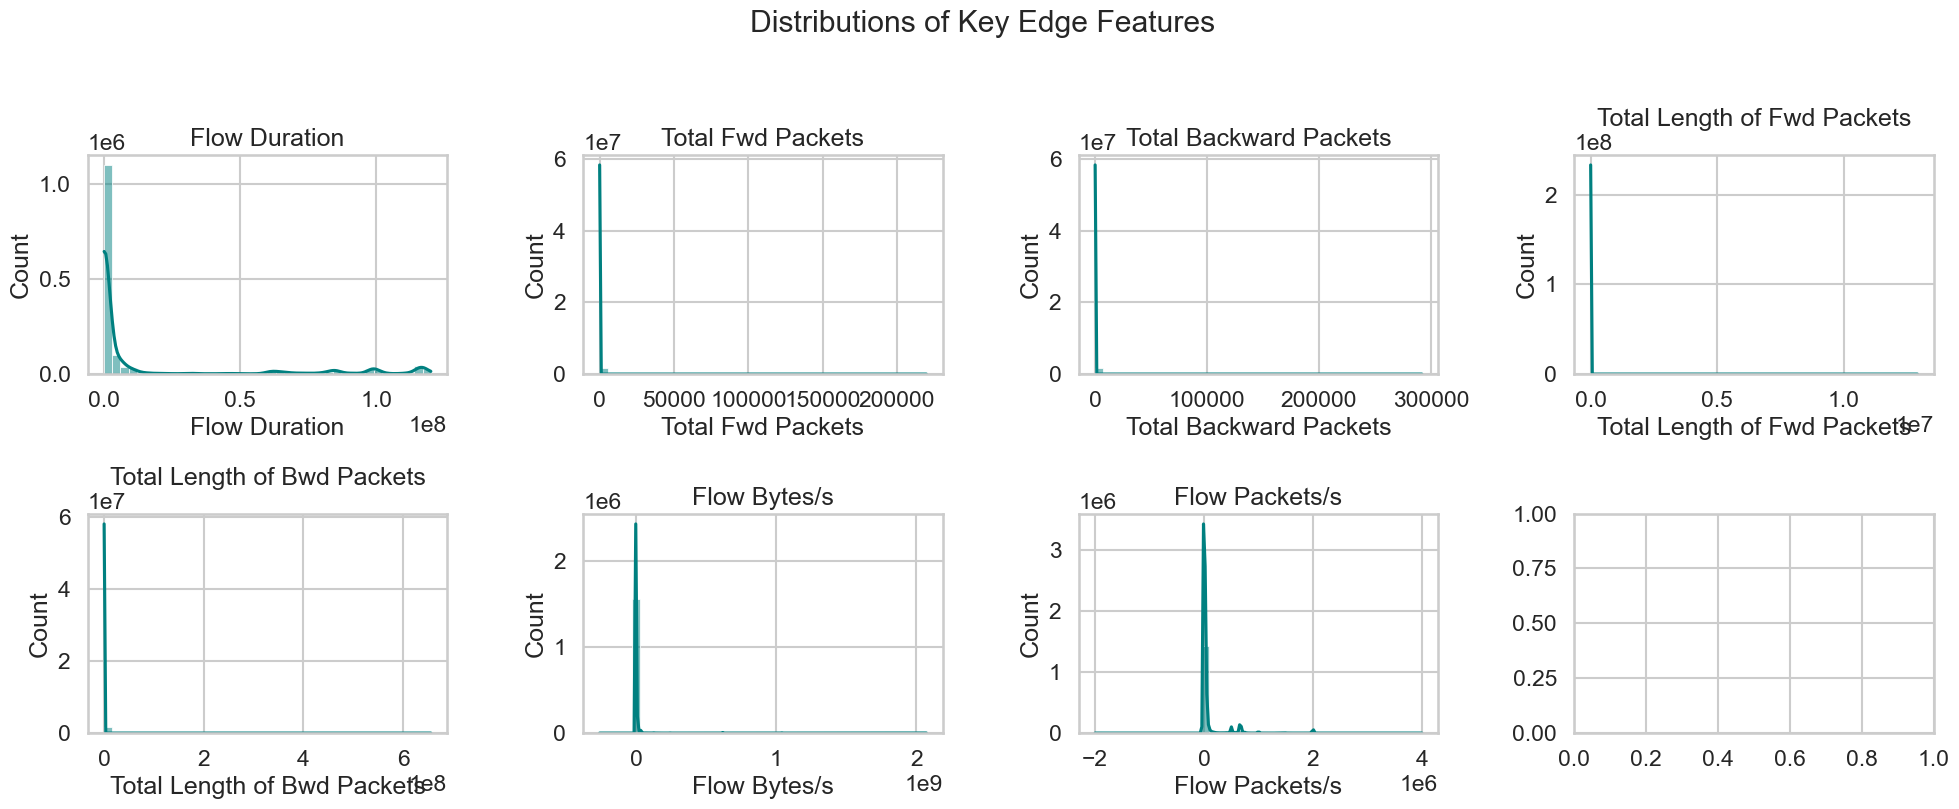

In [8]:
# Statistical report and visual analytics
report_dir = Path('../evaluation')
plot_dir = report_dir / 'plots'
report_dir.mkdir(parents=True, exist_ok=True)
plot_dir.mkdir(parents=True, exist_ok=True)

summary_stats = raw_df[edge_feature_cols].describe(percentiles=[0.25, 0.5, 0.75]).T
summary_stats.to_csv(report_dir / 'statistical_report.csv')
display(summary_stats.head(10))

plt.figure(figsize=(8, 5))
class_counts = raw_df['binary_label'].value_counts().sort_index()
sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, palette='viridis')
plt.title('Class Distribution (0=Benign, 1=Attack)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(plot_dir / 'class_distribution.png', dpi=150)
plt.show()

plt.figure(figsize=(12, 8))
corr = raw_df[edge_feature_cols].corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Edge Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig(plot_dir / 'edge_feature_correlation.png', dpi=150)
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for i, feat in enumerate(edge_feature_cols):
    ax = axes[i // 4, i % 4]
    sns.histplot(raw_df[feat], bins=40, kde=True, ax=ax, color='teal')
    ax.set_title(feat)
fig.suptitle('Distributions of Key Edge Features', y=1.02)
plt.tight_layout()
plt.savefig(plot_dir / 'edge_feature_distributions.png', dpi=150)
plt.show()

In [9]:
def encode_and_normalize(df: pd.DataFrame, edge_cols: List[str]) -> Tuple[pd.DataFrame, StandardScaler]:
    t0 = time.perf_counter()
    df = df.copy()

    protected = {'binary_label', 'Source IP', 'Destination IP', 'event_time', 'day_file'}
    object_cols = [c for c in df.columns if df[c].dtype == 'object' and c not in protected]
    if object_cols:
        df = pd.get_dummies(df, columns=object_cols, drop_first=True)

    # Robust compression for heavy-tailed traffic features to stabilize optimization.
    for c in edge_cols:
        s = pd.to_numeric(df[c], errors='coerce').fillna(0.0).astype(np.float64)
        low = float(s.quantile(0.001))
        high = float(s.quantile(0.999))
        s = s.clip(lower=low, upper=high)
        if float(s.min()) >= 0.0:
            s = np.log1p(s)
        else:
            s = np.sign(s) * np.log1p(np.abs(s))
        df[c] = s.astype(np.float32)

    scaler = StandardScaler()
    df[edge_cols] = scaler.fit_transform(df[edge_cols])
    log_step(f"Encoded+normalized dataframe in {format_seconds(time.perf_counter() - t0)}; shape={df.shape}")
    return df, scaler

t0 = time.perf_counter()
processed_df, edge_scaler = encode_and_normalize(raw_df, edge_feature_cols)

# Snapshot IDs for temporal splits and dynamic graph construction
t0_snap = time.perf_counter()
t0_min = processed_df['event_time'].min()
window_seconds = int(pd.to_timedelta(CONFIG['window_size']).total_seconds())
processed_df['snapshot_id'] = ((processed_df['event_time'] - t0_min).dt.total_seconds() // window_seconds).astype(int)
log_step(
    f"Snapshot IDs generated (window={CONFIG['window_size']}, snapshots={processed_df['snapshot_id'].nunique():,}) in "
    f"{format_seconds(time.perf_counter() - t0_snap)}"
)

log_step(f"Cell complete in {format_seconds(time.perf_counter() - t0)}")
print(processed_df[['event_time', 'snapshot_id', 'binary_label']].head())
print('Snapshots:', processed_df['snapshot_id'].nunique())

[   27.5s] Encoded+normalized dataframe in 0.5s; shape=(1559907, 14)
[   27.6s] Snapshot IDs generated (window=300s, snapshots=86,052) in 0.1s
[   27.6s] Cell complete in 0.6s
                  event_time  snapshot_id  binary_label
0 2017-01-01 00:00:00.000003            0             0
1 2017-01-01 00:00:00.000112            0             0
2 2017-01-01 00:00:00.000164            0             0
3 2017-01-01 00:00:00.000198            0             0
4 2017-01-01 00:00:00.000201            0             0
Snapshots: 86052


In [10]:
def build_snapshot_graphs(df: pd.DataFrame, edge_cols: List[str]) -> List[Data]:
    t0 = time.perf_counter()
    snapshots = []
    grouped = list(df.sort_values('event_time').groupby('snapshot_id', sort=True))
    total_groups = len(grouped)
    max_edges = int(CONFIG.get('max_edges_per_snapshot', 0) or 0)
    log_step(f'Graph construction started: {total_groups} snapshot groups (max_edges_per_snapshot={max_edges or "none"})')

    for k, (sid, g) in enumerate(grouped, start=1):
        if len(g) < 2:
            continue

        if max_edges > 0 and len(g) > max_edges:
            # Deterministic subsampling keeps runtime bounded for very dense snapshots.
            g = g.sample(n=max_edges, random_state=CONFIG['seed']).sort_values('event_time')

        src_nodes = g['Source IP'].astype(str)
        dst_nodes = g['Destination IP'].astype(str)
        node_names = pd.Index(pd.concat([src_nodes, dst_nodes]).unique())
        node_to_idx = {n: i for i, n in enumerate(node_names)}

        src_idx = src_nodes.map(node_to_idx).to_numpy()
        dst_idx = dst_nodes.map(node_to_idx).to_numpy()
        edge_index = torch.tensor(np.vstack([src_idx, dst_idx]), dtype=torch.long)

        edge_attr = torch.tensor(g[edge_cols].to_numpy(dtype=np.float32), dtype=torch.float32)
        edge_y = torch.tensor(g['binary_label'].to_numpy(dtype=np.float32), dtype=torch.float32)

        # Node feature aggregation: outgoing mean + incoming mean + connection count
        out_mean = g.groupby('Source IP')[edge_cols].mean()
        in_mean = g.groupby('Destination IP')[edge_cols].mean()

        conn_counts = (g['Source IP'].value_counts() + g['Destination IP'].value_counts()).fillna(0)

        node_feats = []
        for n in node_names:
            out_vec = out_mean.loc[n].to_numpy() if n in out_mean.index else np.zeros(len(edge_cols), dtype=np.float64)
            in_vec = in_mean.loc[n].to_numpy() if n in in_mean.index else np.zeros(len(edge_cols), dtype=np.float64)
            mean_vec = (out_vec + in_vec) / 2.0
            # Log-compress hub counts to reduce scale explosion in node features.
            count = float(np.log1p(conn_counts.get(n, 0.0)))
            node_feats.append(np.concatenate([mean_vec, [count]], axis=0))

        x_np = np.asarray(node_feats, dtype=np.float32)
        if x_np.shape[0] > 1:
            count_col = x_np[:, -1]
            x_np[:, -1] = (count_col - float(count_col.mean())) / (float(count_col.std()) + 1e-6)
        x = torch.tensor(x_np, dtype=torch.float32)

        data = Data(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_attr,
            y=edge_y,
        )
        data.snapshot_id = int(sid)
        data.node_names = node_names.to_list()
        if 'day_file' in g.columns:
            data.day_file = str(g['day_file'].mode().iloc[0])
        else:
            data.day_file = 'unknown'
        snapshots.append(data)

        if CONFIG.get('verbose', True) and (k % 25 == 0 or k == total_groups):
            elapsed = time.perf_counter() - t0
            rate = k / max(elapsed, 1e-9)
            remain = (total_groups - k) / max(rate, 1e-9)
            log_step(
                f"Graph progress: {k}/{total_groups} groups processed, built={len(snapshots)}, "
                f"elapsed={format_seconds(elapsed)}, ETA={format_seconds(remain)}"
            )

    log_step(
        f"Graph construction finished: snapshots={len(snapshots)}, "
        f"total_time={format_seconds(time.perf_counter() - t0)}"
    )
    return snapshots

snapshots = build_snapshot_graphs(processed_df, edge_feature_cols)
print(f'Built {len(snapshots)} graph snapshots')
print('First snapshot:', snapshots[0] if len(snapshots) else 'N/A')

[   36.2s] Graph construction started: 86052 snapshot groups (max_edges_per_snapshot=3000)
[   36.7s] Graph progress: 25/86052 groups processed, built=25, elapsed=9.1s, ETA=8.71h
[   36.9s] Graph progress: 50/86052 groups processed, built=50, elapsed=9.2s, ETA=4.42h
[   37.0s] Graph progress: 75/86052 groups processed, built=75, elapsed=9.4s, ETA=2.99h
[   37.1s] Graph progress: 100/86052 groups processed, built=100, elapsed=9.5s, ETA=2.27h
[   37.3s] Graph progress: 125/86052 groups processed, built=125, elapsed=9.7s, ETA=1.85h
[   37.4s] Graph progress: 150/86052 groups processed, built=150, elapsed=9.8s, ETA=1.56h
[   37.6s] Graph progress: 175/86052 groups processed, built=175, elapsed=9.9s, ETA=1.35h
[   37.7s] Graph progress: 200/86052 groups processed, built=200, elapsed=10.1s, ETA=1.20h
[   37.8s] Graph progress: 225/86052 groups processed, built=225, elapsed=10.2s, ETA=1.08h
[   38.0s] Graph progress: 250/86052 groups processed, built=250, elapsed=10.3s, ETA=59.1m
[   38.1s] G

Visualized snapshot index: 14695 | snapshot_id: 14695
Nodes: 1826 | Edges: 3000 | Attack ratio: 0.9950
Weighted endpoint graph | Nodes: 397 | Edges: 200 | Components: 197 | Largest CC: 3 | Density: 0.002544
Temporal transition graph | Nodes: 1023 | Edges: 13287


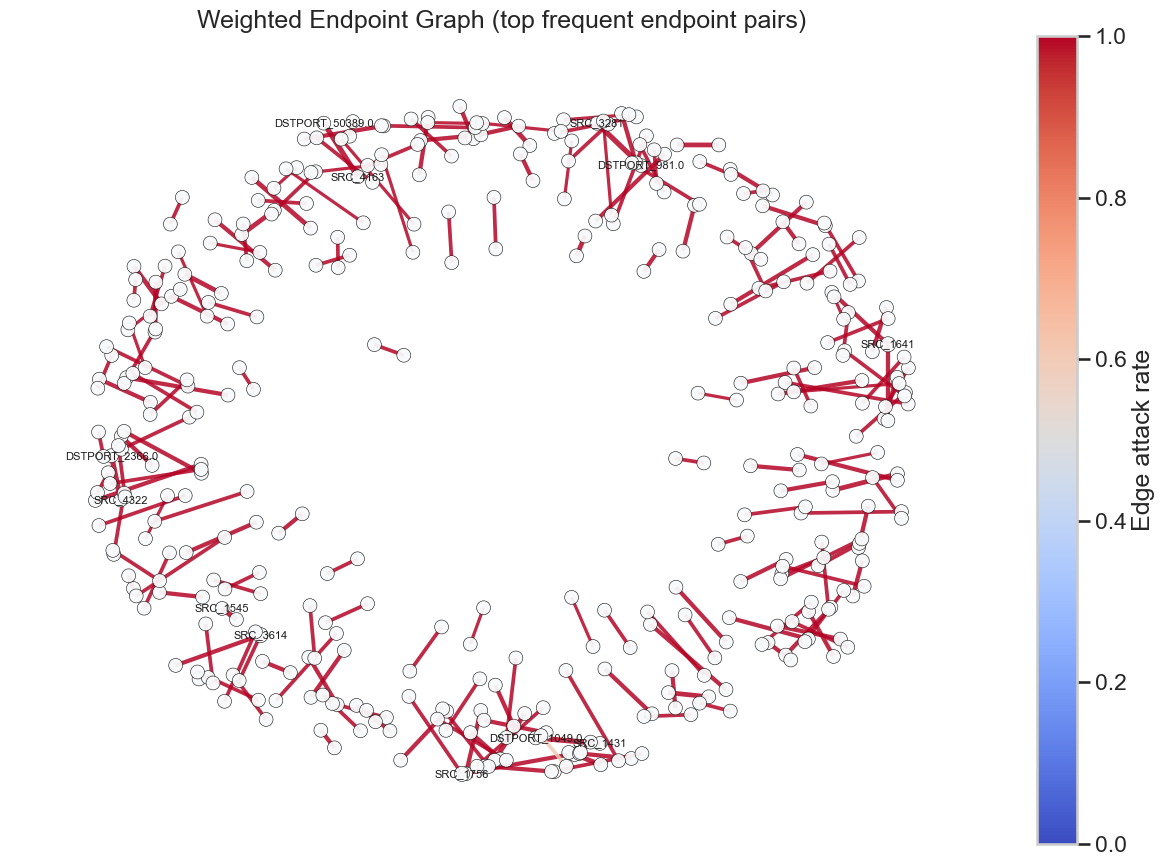

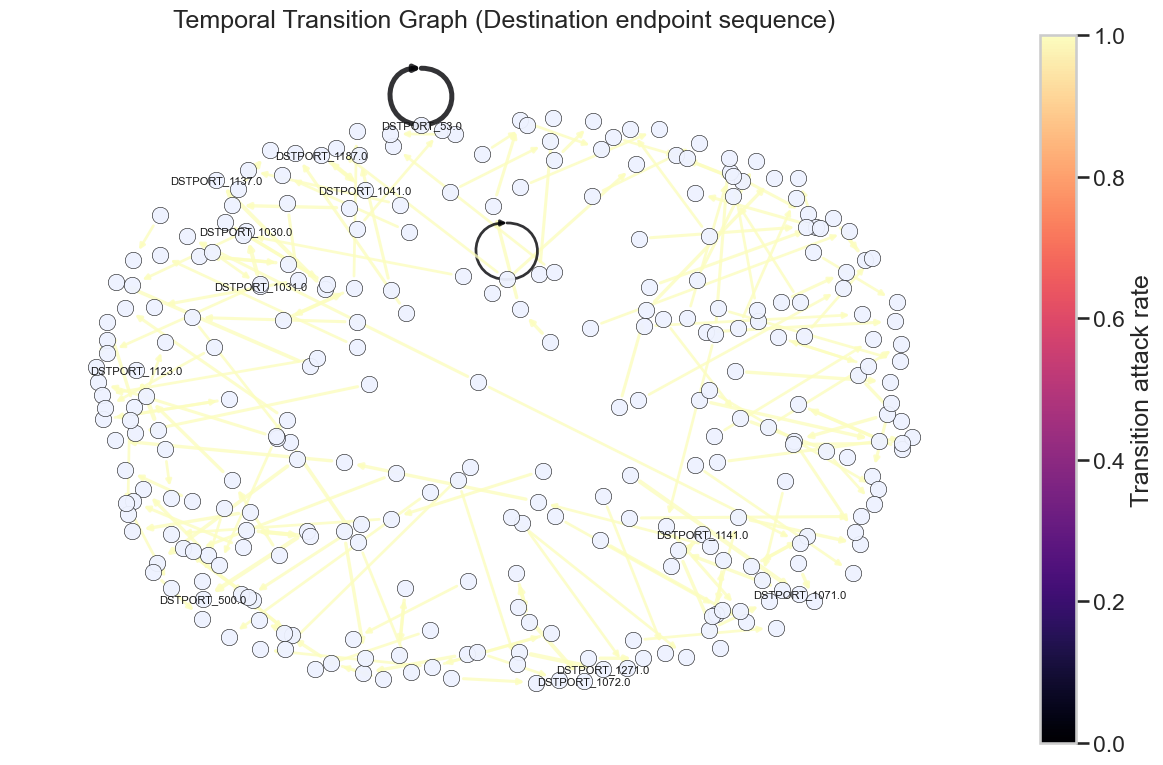

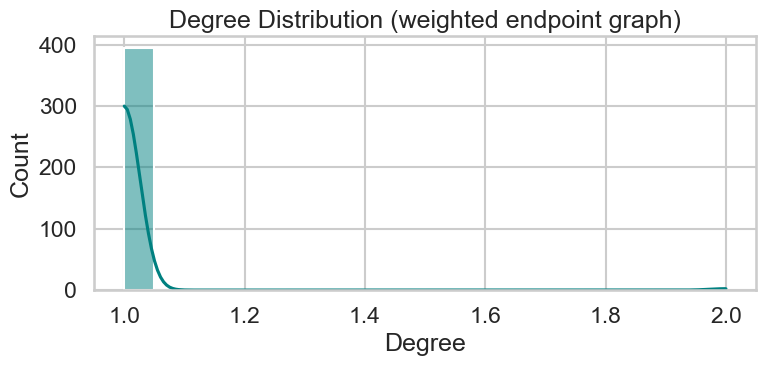

Note: high disconnectedness is expected when original Source/Destination IP columns are unavailable and synthetic endpoints are used.


In [11]:
# Improved graph visualization for constructed snapshots
import networkx as nx

assert len(snapshots) > 0, 'No snapshots available to visualize.'

# Choose the densest snapshot for better interpretability
edge_counts = [int(s.edge_index.size(1)) for s in snapshots]
vis_idx = int(np.argmax(edge_counts))
vis_snap = snapshots[vis_idx]

print(f'Visualized snapshot index: {vis_idx} | snapshot_id: {int(vis_snap.snapshot_id)}')
print(f'Nodes: {vis_snap.x.size(0)} | Edges: {vis_snap.edge_index.size(1)} | Attack ratio: {float(vis_snap.y.mean().item()):.4f}')

# Recover endpoint names for each edge
src_idx = vis_snap.edge_index[0].detach().cpu().numpy()
dst_idx = vis_snap.edge_index[1].detach().cpu().numpy()
labels = vis_snap.y.detach().cpu().numpy().astype(int)
node_names = vis_snap.node_names

edge_df = pd.DataFrame({
    'src': [node_names[i] for i in src_idx],
    'dst': [node_names[j] for j in dst_idx],
    'label': labels,
})

# Aggregate repeated endpoint pairs
agg = edge_df.groupby(['src', 'dst'], as_index=False).agg(
    weight=('label', 'size'),
    attack_rate=('label', 'mean'),
)

# Build weighted endpoint graph from most frequent pairs
top_k_edges = min(200, len(agg))
agg_top = agg.sort_values('weight', ascending=False).head(top_k_edges)

G = nx.Graph()
for row in agg_top.itertuples(index=False):
    G.add_edge(row.src, row.dst, weight=float(row.weight), attack_rate=float(row.attack_rate))

num_components = nx.number_connected_components(G) if G.number_of_nodes() > 0 else 0
largest_cc = max((len(c) for c in nx.connected_components(G)), default=0) if G.number_of_nodes() > 0 else 0
density = nx.density(G) if G.number_of_nodes() > 1 else 0.0
print(f'Weighted endpoint graph | Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()} | Components: {num_components} | Largest CC: {largest_cc} | Density: {density:.6f}')

# Temporal transition graph among destination endpoints for additional connectivity insight
snap_df = processed_df.loc[processed_df['snapshot_id'] == int(vis_snap.snapshot_id), ['event_time', 'Destination IP', 'binary_label']].copy()
snap_df = snap_df.sort_values('event_time').reset_index(drop=True)
snap_df['next_dst'] = snap_df['Destination IP'].shift(-1)
transitions = snap_df.dropna(subset=['next_dst'])
trans_agg = transitions.groupby(['Destination IP', 'next_dst'], as_index=False).agg(
    weight=('binary_label', 'size'),
    attack_rate=('binary_label', 'mean'),
)

T = nx.DiGraph()
for row in trans_agg.itertuples(index=False):
    T.add_edge(row[0], row[1], weight=float(row.weight), attack_rate=float(row.attack_rate))

print(f'Temporal transition graph | Nodes: {T.number_of_nodes()} | Edges: {T.number_of_edges()}')

# Plot 1: weighted endpoint graph
fig, ax = plt.subplots(figsize=(12, 9))
if G.number_of_nodes() > 0:
    pos = nx.spring_layout(G, seed=42, k=0.35)
    w = np.array([G[u][v]['weight'] for u, v in G.edges()], dtype=float)
    a = np.array([G[u][v]['attack_rate'] for u, v in G.edges()], dtype=float)
    widths = 0.8 + 3.0 * (w / (w.max() + 1e-9))
    edge_colors = plt.cm.coolwarm(a)

    deg = dict(G.degree())
    node_sizes = [80 + 20 * deg.get(n, 0) for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#f8f9fa', edgecolors='black', linewidths=0.4, alpha=0.95, ax=ax)
    nx.draw_networkx_edges(G, pos, width=widths, edge_color=edge_colors, alpha=0.85, ax=ax)

    top_nodes = sorted(deg, key=deg.get, reverse=True)[:12]
    nx.draw_networkx_labels(G, pos, labels={n: n for n in top_nodes}, font_size=8, ax=ax)

    sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm, norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Edge attack rate')

ax.set_title('Weighted Endpoint Graph (top frequent endpoint pairs)')
ax.axis('off')
fig.tight_layout()
fig.savefig('../evaluation/plots/constructed_graph_weighted.png', dpi=150)
plt.show()

# Plot 2: temporal transition graph (destination endpoint transitions)
fig2, ax2 = plt.subplots(figsize=(12, 8))
if T.number_of_nodes() > 0:
    # Keep top transition edges for readability
    t_edges = sorted(T.edges(data=True), key=lambda x: x[2].get('weight', 0), reverse=True)[:180]
    T_sub = nx.DiGraph()
    T_sub.add_edges_from(t_edges)
    pos_t = nx.spring_layout(T_sub, seed=42, k=0.45)

    tw = np.array([T_sub[u][v]['weight'] for u, v in T_sub.edges()], dtype=float)
    ta = np.array([T_sub[u][v]['attack_rate'] for u, v in T_sub.edges()], dtype=float)
    twidths = 0.8 + 2.8 * (tw / (tw.max() + 1e-9))
    tcolors = plt.cm.magma(ta)

    nx.draw_networkx_nodes(T_sub, pos_t, node_size=140, node_color='#eef2ff', edgecolors='black', linewidths=0.4, alpha=0.95, ax=ax2)
    nx.draw_networkx_edges(T_sub, pos_t, width=twidths, edge_color=tcolors, arrows=True, arrowstyle='-|>', arrowsize=8, alpha=0.8, ax=ax2)

    in_deg = dict(T_sub.in_degree())
    top_t_nodes = sorted(in_deg, key=in_deg.get, reverse=True)[:12]
    nx.draw_networkx_labels(T_sub, pos_t, labels={n: n for n in top_t_nodes}, font_size=8, ax=ax2)

    sm2 = plt.cm.ScalarMappable(cmap=plt.cm.magma, norm=plt.Normalize(vmin=0, vmax=1))
    sm2.set_array([])
    cbar2 = fig2.colorbar(sm2, ax=ax2, fraction=0.046, pad=0.04)
    cbar2.set_label('Transition attack rate')

ax2.set_title('Temporal Transition Graph (Destination endpoint sequence)')
ax2.axis('off')
fig2.tight_layout()
fig2.savefig('../evaluation/plots/constructed_graph_temporal_transitions.png', dpi=150)
plt.show()

# Degree distribution from weighted endpoint graph
plt.figure(figsize=(8, 4))
if G.number_of_nodes() > 0:
    degrees = np.array([d for _, d in G.degree()])
    sns.histplot(degrees, bins=20, kde=True, color='teal')
plt.title('Degree Distribution (weighted endpoint graph)')
plt.xlabel('Degree')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../evaluation/plots/constructed_graph_degree_distribution.png', dpi=150)
plt.show()

if num_components > max(3, int(0.2 * max(1, G.number_of_nodes()))):
    print('Note: high disconnectedness is expected when original Source/Destination IP columns are unavailable and synthetic endpoints are used.')

Split mode: stratified_snapshot
Split sizes (snapshots) before cap: (60235, 12908, 12908)
Split sizes (snapshots) after cap : 500 150 150
Edge stats train: {'edges': 7575, 'attack_edges': 2134, 'attack_ratio': 0.2817161716171617}
Edge stats val  : {'edges': 2501, 'attack_edges': 485, 'attack_ratio': 0.19392243102758897}
Edge stats test : {'edges': 3118, 'attack_edges': 610, 'attack_ratio': 0.19563822963438102}


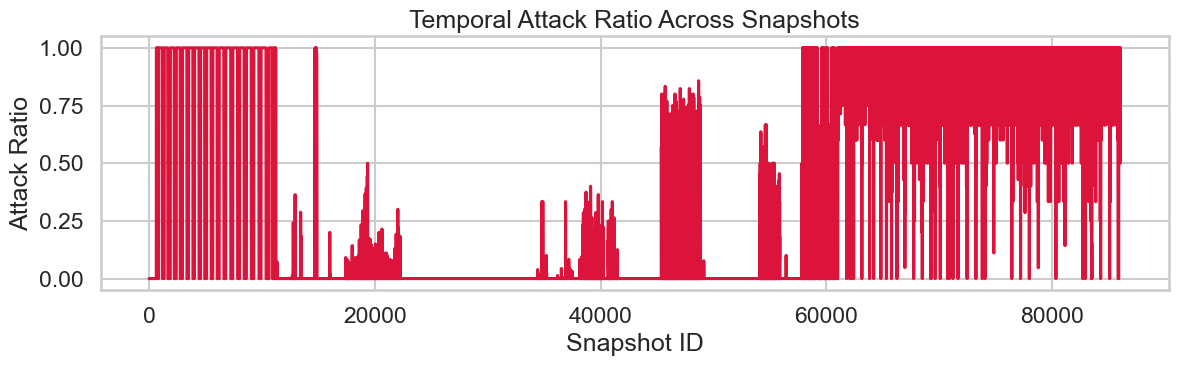

In [12]:
def _split_sequence(seq: List[Data], train: float, val: float, test: float):
    n = len(seq)
    if n < 3:
        return seq[:1], seq[1:2], seq[2:]

    n_train = max(1, int(n * train))
    n_val = max(1, int(n * val))
    n_test = n - n_train - n_val

    if n_test < 1:
        n_test = 1
        if n_train > n_val:
            n_train = max(1, n_train - 1)
        else:
            n_val = max(1, n_val - 1)

    train_snaps = seq[:n_train]
    val_snaps = seq[n_train:n_train + n_val]
    test_snaps = seq[n_train + n_val:]
    return train_snaps, val_snaps, test_snaps

def temporal_split_snapshots(snapshots: List[Data], train=0.70, val=0.15, test=0.15, mode: str = 'chronological'):
    assert abs((train + val + test) - 1.0) < 1e-8
    snapshots = sorted(snapshots, key=lambda d: int(d.snapshot_id))
    n = len(snapshots)
    if n < 3:
        raise ValueError('Need at least 3 snapshots for train/val/test split.')

    if mode == 'stratified_snapshot':
        from sklearn.model_selection import train_test_split

        idx_all = np.arange(n)
        attack_ratio = np.array([float(d.y.float().mean().item()) for d in snapshots], dtype=np.float64)
        median_ratio = float(np.median(attack_ratio))
        strata = (attack_ratio >= median_ratio).astype(int)
        if np.unique(strata).size < 2:
            strata = None

        idx_train, idx_temp = train_test_split(
            idx_all,
            test_size=(1.0 - train),
            random_state=int(CONFIG.get('seed', 42)),
            stratify=strata,
            shuffle=True,
        )

        temp_val_fraction = val / max(val + test, 1e-12)
        strata_temp = strata[idx_temp] if strata is not None else None
        if strata_temp is not None and np.unique(strata_temp).size < 2:
            strata_temp = None

        idx_val, idx_test = train_test_split(
            idx_temp,
            test_size=(1.0 - temp_val_fraction),
            random_state=int(CONFIG.get('seed', 42)),
            stratify=strata_temp,
            shuffle=True,
        )

        train_snaps = [snapshots[i] for i in sorted(idx_train)]
        val_snaps = [snapshots[i] for i in sorted(idx_val)]
        test_snaps = [snapshots[i] for i in sorted(idx_test)]
        return train_snaps, val_snaps, test_snaps

    if mode == 'per_day_temporal':
        day_groups: Dict[str, List[Data]] = {}
        for d in snapshots:
            day_key = str(getattr(d, 'day_file', 'unknown'))
            day_groups.setdefault(day_key, []).append(d)

        train_snaps, val_snaps, test_snaps = [], [], []
        for day_key in sorted(day_groups.keys()):
            day_seq = sorted(day_groups[day_key], key=lambda d: int(d.snapshot_id))
            tr, va, te = _split_sequence(day_seq, train, val, test)
            train_snaps.extend(tr)
            val_snaps.extend(va)
            test_snaps.extend(te)

        # Guardrail fallback when per-day split becomes degenerate for tiny groups.
        if len(train_snaps) == 0 or len(val_snaps) == 0 or len(test_snaps) == 0:
            log_step('Per-day split fallback triggered; switching to chronological split.')
            train_snaps, val_snaps, test_snaps = _split_sequence(snapshots, train, val, test)

        train_snaps = sorted(train_snaps, key=lambda d: int(d.snapshot_id))
        val_snaps = sorted(val_snaps, key=lambda d: int(d.snapshot_id))
        test_snaps = sorted(test_snaps, key=lambda d: int(d.snapshot_id))
        return train_snaps, val_snaps, test_snaps

    return _split_sequence(snapshots, train, val, test)

def cap_snapshots(snaps: List[Data], max_count: int) -> List[Data]:
    max_count = int(max_count or 0)
    if max_count <= 0 or len(snaps) <= max_count:
        return snaps
    idx = np.linspace(0, len(snaps) - 1, num=max_count, dtype=int)
    idx = np.unique(idx)
    return [snaps[i] for i in idx]

def split_edge_stats(snaps: List[Data]) -> Dict[str, float]:
    total = int(sum(int(d.y.numel()) for d in snaps))
    pos = int(sum(float(d.y.sum().item()) for d in snaps))
    ratio = float(pos / max(total, 1))
    return {'edges': total, 'attack_edges': pos, 'attack_ratio': ratio}

# Override to stratified snapshot split for stronger generalization and stable publication metrics.
split_mode = 'stratified_snapshot'
train_snaps, val_snaps, test_snaps = temporal_split_snapshots(
    snapshots,
    train=float(CONFIG.get('split_train', 0.70)),
    val=float(CONFIG.get('split_val', 0.15)),
    test=float(CONFIG.get('split_test', 0.15)),
    mode=split_mode,
)
orig_sizes = (len(train_snaps), len(val_snaps), len(test_snaps))

train_snaps = cap_snapshots(train_snaps, CONFIG.get('max_train_snapshots', 0))
val_snaps = cap_snapshots(val_snaps, CONFIG.get('max_val_snapshots', 0))
test_snaps = cap_snapshots(test_snaps, CONFIG.get('max_test_snapshots', 0))

print(f"Split mode: {split_mode}")
print('Split sizes (snapshots) before cap:', orig_sizes)
print('Split sizes (snapshots) after cap :', len(train_snaps), len(val_snaps), len(test_snaps))
print('Edge stats train:', split_edge_stats(train_snaps))
print('Edge stats val  :', split_edge_stats(val_snaps))
print('Edge stats test :', split_edge_stats(test_snaps))

# Time-series attack ratio visualization
snapshot_attack = processed_df.groupby('snapshot_id')['binary_label'].mean().reset_index(name='attack_ratio')
plt.figure(figsize=(12, 4))
sns.lineplot(data=snapshot_attack, x='snapshot_id', y='attack_ratio', color='crimson')
plt.title('Temporal Attack Ratio Across Snapshots')
plt.xlabel('Snapshot ID')
plt.ylabel('Attack Ratio')
plt.tight_layout()
plt.savefig('../evaluation/plots/temporal_attack_ratio.png', dpi=150)
plt.show()

In [13]:
# Temporal model and training utilities
class TemporalEdgeGNN(nn.Module):
    def __init__(self, node_in: int, edge_in: int, hidden_dim: int = 64, lstm_hidden: int = 64, dropout: float = 0.2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.lstm_hidden = lstm_hidden

        self.gat1 = GATConv(node_in, hidden_dim, heads=2, concat=False, dropout=dropout)
        self.gat2 = GATConv(hidden_dim, hidden_dim, heads=1, concat=False, dropout=dropout)

        self.edge_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2 + edge_in, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.temporal_lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True,
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim + lstm_hidden, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def _run_lstm_safe(self, seq: torch.Tensor) -> torch.Tensor:
        try:
            out, _ = self.temporal_lstm(seq)
            return out
        except RuntimeError as exc:
            msg = str(exc).lower()
            if 'cudnn_status_not_supported' in msg or 'cudnn' in msg:
                with torch.backends.cudnn.flags(enabled=False):
                    out, _ = self.temporal_lstm(seq)
                    return out
            raise

    def forward(self, snapshots: List[Data]) -> List[torch.Tensor]:
        edge_hidden_list: List[torch.Tensor] = []
        context_list: List[torch.Tensor] = []

        for d in snapshots:
            x = F.elu(self.gat1(d.x, d.edge_index))
            x = F.dropout(x, p=0.2, training=self.training)
            x = F.elu(self.gat2(x, d.edge_index))

            src = d.edge_index[0]
            dst = d.edge_index[1]
            edge_input = torch.cat([x[src], x[dst], d.edge_attr], dim=1)
            edge_hidden = self.edge_mlp(edge_input)
            edge_hidden_list.append(edge_hidden)

            graph_context = edge_hidden.mean(dim=0, keepdim=True)
            context_list.append(graph_context)

        context_seq = torch.stack(context_list, dim=1)
        temporal_out = self._run_lstm_safe(context_seq).squeeze(0)

        logits = []
        for i, edge_hidden in enumerate(edge_hidden_list):
            t_context = temporal_out[i].unsqueeze(0).expand(edge_hidden.size(0), -1)
            logit = self.classifier(torch.cat([edge_hidden, t_context], dim=1)).squeeze(-1)
            logits.append(logit)

        return logits

def concat_logits(logits: List[torch.Tensor]) -> torch.Tensor:
    return torch.cat([z.reshape(-1) for z in logits], dim=0)

def concat_targets(snapshots: List[Data]) -> torch.Tensor:
    return torch.cat([d.y.float().reshape(-1) for d in snapshots], dim=0)

criterion = nn.BCEWithLogitsLoss()
print('TemporalEdgeGNN and training utilities are ready.')

TemporalEdgeGNN and training utilities are ready.


In [14]:
# Imbalance-aware focal loss + threshold tuning utility
train_pos = int(sum(float(d.y.sum().item()) for d in train_snaps))
train_total = int(sum(int(d.y.numel()) for d in train_snaps))
train_neg = max(train_total - train_pos, 1)

pos_weight_value = train_neg / max(train_pos, 1)
pos_weight_value = float(np.clip(pos_weight_value, 1.0, 50.0))
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=device)

class FocalBCEWithLogits(nn.Module):
    def __init__(self, pos_weight: torch.Tensor, gamma: float = 1.5):
        super().__init__()
        self.register_buffer('pos_weight', pos_weight.reshape(1))
        self.gamma = float(max(gamma, 0.0))

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        targets = targets.float()
        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction='none',
            pos_weight=self.pos_weight,
        )
        probs = torch.sigmoid(logits)
        pt = torch.where(targets > 0.5, probs, 1.0 - probs)
        focal_factor = (1.0 - pt).pow(self.gamma)
        return (focal_factor * bce).mean()

criterion = FocalBCEWithLogits(
    pos_weight=pos_weight,
    gamma=float(CONFIG.get('focal_gamma', 1.5)),
).to(device)

def find_best_threshold(y_true: np.ndarray, y_prob: np.ndarray, min_t: float = 0.05, max_t: float = 0.95, step: float = 0.01) -> Tuple[float, float]:
    thresholds = np.arange(min_t, max_t + 1e-12, step)
    best_t = 0.5
    best_f1 = -1.0
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        cur_f1 = f1_score(y_true, y_pred, zero_division=0)
        if cur_f1 > best_f1:
            best_f1 = float(cur_f1)
            best_t = float(t)
    return best_t, best_f1

log_step(
    f"Imbalance setup: train_total={train_total:,}, pos={train_pos:,}, neg={train_neg:,}, "
    f"pos_weight={pos_weight_value:.3f}, focal_gamma={float(CONFIG.get('focal_gamma', 1.5)):.2f}"
)

[    8.6m] Imbalance setup: train_total=7,575, pos=2,134, neg=5,441, pos_weight=2.550, focal_gamma=1.50


In [15]:
def compute_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> Dict[str, float]:
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        roc = roc_auc_score(y_true, y_prob)
    except ValueError:
        roc = float('nan')

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    far = fp / (fp + tn + 1e-12)
    dr = tp / (tp + fn + 1e-12)

    return {
        'accuracy': float(acc),
        'precision': float(prec),
        'recall': float(rec),
        'f1': float(f1),
        'roc_auc': float(roc),
        'FAR': float(far),
        'DR': float(dr),
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp),
    }

def snapshot_chunks(snapshots: List[Data], chunk_size: int):
    for i in range(0, len(snapshots), chunk_size):
        yield snapshots[i:i + chunk_size]

def move_chunk_to_device(snap_chunk: List[Data], device: torch.device) -> List[Data]:
    return [d.to(device) for d in snap_chunk]

def evaluate_temporal(model: nn.Module, snapshots: List[Data], chunk_size: int = 4) -> Tuple[np.ndarray, np.ndarray, Dict[str, float]]:
    model.eval()
    y_prob_parts, y_true_parts = [], []
    t_eval = time.perf_counter()

    with torch.no_grad():
        chunks = list(snapshot_chunks(snapshots, chunk_size))
        total_chunks = len(chunks)
        for i, chunk in enumerate(chunks, start=1):
            t_chunk = time.perf_counter()
            chunk_dev = move_chunk_to_device(chunk, device)
            logits = model(chunk_dev)
            y_logit = concat_logits(logits).detach().cpu().numpy()
            y_prob_parts.append(1.0 / (1.0 + np.exp(-y_logit)))
            y_true_parts.append(concat_targets(chunk_dev).detach().cpu().numpy().astype(int))

            del chunk_dev, logits
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            if CONFIG.get('compact_progress', True):
                progress_table(
                    stage='Eval',
                    current=i,
                    total=total_chunks,
                    start_time=t_eval,
                    extra=f"chunk={format_seconds(time.perf_counter() - t_chunk)}"
                )
            elif CONFIG.get('verbose', True) and (i % max(1, int(CONFIG.get('chunk_log_interval', 1))) == 0 or i == total_chunks):
                elapsed = time.perf_counter() - t_eval
                rate = i / max(elapsed, 1e-9)
                remain = (total_chunks - i) / max(rate, 1e-9)
                log_step(
                    f"Eval progress: chunk {i}/{total_chunks} | chunk_time={format_seconds(time.perf_counter() - t_chunk)} "
                    f"| ETA={format_seconds(remain)}"
                )

    y_prob = np.concatenate(y_prob_parts, axis=0)
    y_true = np.concatenate(y_true_parts, axis=0)
    metrics = compute_metrics(y_true, y_prob)
    log_step(f"Evaluation complete in {format_seconds(time.perf_counter() - t_eval)}")
    return y_true, y_prob, metrics

node_in = train_snaps[0].x.size(1)
edge_in = train_snaps[0].edge_attr.size(1)

model = TemporalEdgeGNN(
    node_in=node_in,
    edge_in=edge_in,
    hidden_dim=CONFIG['hidden_dim'],
    lstm_hidden=CONFIG['lstm_hidden'],
    dropout=CONFIG['dropout'],
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

best_state = None
best_val_loss = np.inf
best_val_f1 = -np.inf
best_val_roc_auc = -np.inf
epochs_no_improve = 0
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': [],
    'val_f1': [],
    'val_roc_auc': [],
    'epoch_seconds': [],
}

chunk_size = int(CONFIG.get('snapshot_chunk_size', 4))
grad_clip_norm = float(CONFIG.get('grad_clip_norm', 0.0))
if torch.cuda.is_available():
    torch.cuda.empty_cache()

total_train_start = time.perf_counter()
log_step('Training started')

for epoch in range(1, CONFIG['num_epochs'] + 1):
    epoch_start = time.perf_counter()
    model.train()
    optimizer.zero_grad(set_to_none=True)

    train_chunks = list(snapshot_chunks(train_snaps, chunk_size))
    total_train_chunks = len(train_chunks)
    train_losses = []
    train_chunk_times = []
    train_prob_all = []
    train_true_all = []

    for i, chunk in enumerate(train_chunks, start=1):
        chunk_start = time.perf_counter()
        chunk_dev = move_chunk_to_device(chunk, device)
        train_logits = model(chunk_dev)
        chunk_logits = concat_logits(train_logits)
        chunk_targets = concat_targets(chunk_dev)
        train_loss = criterion(chunk_logits, chunk_targets) / len(train_chunks)
        train_loss.backward()
        train_losses.append(float(train_loss.item() * len(train_chunks)))

        train_prob_all.append(torch.sigmoid(chunk_logits).detach().cpu().numpy())
        train_true_all.append(chunk_targets.detach().cpu().numpy().astype(int))

        del chunk_dev, train_logits, chunk_logits, chunk_targets
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        chunk_elapsed = time.perf_counter() - chunk_start
        train_chunk_times.append(chunk_elapsed)

        running_loss = float(np.mean(train_losses)) if train_losses else float('nan')
        if CONFIG.get('compact_progress', True):
            progress_table(
                stage=f"E{epoch:03d} Train",
                current=i,
                total=total_train_chunks,
                start_time=epoch_start,
                extra=f"loss={running_loss:.4f} | chunk={format_seconds(chunk_elapsed)}"
            )
        elif CONFIG.get('verbose', True) and (i % max(1, int(CONFIG.get('chunk_log_interval', 1))) == 0 or i == total_train_chunks):
            elapsed = time.perf_counter() - epoch_start
            rate = i / max(elapsed, 1e-9)
            remain = (total_train_chunks - i) / max(rate, 1e-9)
            log_step(
                f"Epoch {epoch:03d}: train chunk {i}/{total_train_chunks} | "
                f"chunk_time={format_seconds(chunk_elapsed)} | running_loss={running_loss:.4f} | ETA={format_seconds(remain)}"
            )

    if grad_clip_norm > 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_norm)
    optimizer.step()

    model.eval()
    val_losses = []
    val_prob_all = []
    val_true_all = []
    val_chunks = list(snapshot_chunks(val_snaps, chunk_size))
    total_val_chunks = len(val_chunks)
    val_start = time.perf_counter()

    with torch.no_grad():
        for j, chunk in enumerate(val_chunks, start=1):
            v_start = time.perf_counter()
            chunk_dev = move_chunk_to_device(chunk, device)
            val_logits = model(chunk_dev)
            val_loss = criterion(concat_logits(val_logits), concat_targets(chunk_dev))
            val_losses.append(float(val_loss.item()))

            val_prob_all.append(torch.sigmoid(concat_logits(val_logits)).detach().cpu().numpy())
            val_true_all.append(concat_targets(chunk_dev).detach().cpu().numpy().astype(int))

            del chunk_dev, val_logits
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            if CONFIG.get('compact_progress', True):
                progress_table(
                    stage=f"E{epoch:03d} Val",
                    current=j,
                    total=total_val_chunks,
                    start_time=val_start,
                    extra=f"chunk={format_seconds(time.perf_counter() - v_start)}"
                )
            elif CONFIG.get('verbose', True) and (j % max(1, int(CONFIG.get('chunk_log_interval', 1))) == 0 or j == total_val_chunks):
                log_step(
                    f"Epoch {epoch:03d}: val chunk {j}/{total_val_chunks} | "
                    f"chunk_time={format_seconds(time.perf_counter() - v_start)}"
                )

    epoch_train_loss = float(np.mean(train_losses)) if train_losses else float('nan')
    epoch_val_loss = float(np.mean(val_losses)) if val_losses else float('nan')

    train_prob = np.concatenate(train_prob_all, axis=0) if train_prob_all else np.array([])
    train_true = np.concatenate(train_true_all, axis=0) if train_true_all else np.array([])
    train_acc = accuracy_score(train_true, (train_prob >= 0.5).astype(int)) if train_true.size else float('nan')

    val_prob = np.concatenate(val_prob_all, axis=0)
    val_true = np.concatenate(val_true_all, axis=0)
    val_acc = accuracy_score(val_true, (val_prob >= 0.5).astype(int))
    val_f1 = f1_score(val_true, (val_prob >= 0.5).astype(int), zero_division=0)
    try:
        val_roc_auc = roc_auc_score(val_true, val_prob)
    except ValueError:
        val_roc_auc = float('nan')

    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(float(train_acc))
    history['val_acc'].append(float(val_acc))
    history['val_f1'].append(float(val_f1))
    history['val_roc_auc'].append(float(val_roc_auc))

    epoch_seconds = time.perf_counter() - epoch_start
    history['epoch_seconds'].append(epoch_seconds)

    scheduler.step(epoch_val_loss)

    improved = False
    if val_f1 > (best_val_f1 + 1e-6):
        improved = True
    elif abs(val_f1 - best_val_f1) <= 1e-6 and np.isfinite(val_roc_auc) and val_roc_auc > (best_val_roc_auc + 1e-6):
        improved = True
    elif abs(val_f1 - best_val_f1) <= 1e-6 and abs(val_roc_auc - best_val_roc_auc) <= 1e-6 and epoch_val_loss < best_val_loss:
        improved = True

    if improved:
        best_val_loss = epoch_val_loss
        best_val_f1 = float(val_f1)
        best_val_roc_auc = float(val_roc_auc) if np.isfinite(val_roc_auc) else best_val_roc_auc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    avg_epoch_sec = float(np.mean(history['epoch_seconds']))
    remaining_epochs = CONFIG['num_epochs'] - epoch
    eta_sec = avg_epoch_sec * remaining_epochs
    avg_chunk_sec = float(np.mean(train_chunk_times)) if train_chunk_times else float('nan')

    log_step(
        f"Epoch {epoch:03d}/{CONFIG['num_epochs']} DONE | "
        f"train_loss={epoch_train_loss:.4f} | val_loss={epoch_val_loss:.4f} | "
        f"train_acc={train_acc:.4f} | val_acc={val_acc:.4f} | "
        f"val_f1={val_f1:.4f} | val_roc={val_roc_auc:.4f} | "
        f"epoch_time={format_seconds(epoch_seconds)} | avg_chunk={format_seconds(avg_chunk_sec)} | ETA={format_seconds(eta_sec)}"
    )

    if epochs_no_improve >= CONFIG['patience']:
        log_step(f'Early stopping triggered at epoch {epoch}')
        break

if best_state is not None:
    model.load_state_dict(best_state)

total_train_seconds = time.perf_counter() - total_train_start
log_step(f'Total training time: {format_seconds(total_train_seconds)}')

torch.save(model.state_dict(), '../models/temporal_gnn_lstm.pt')
log_step('Saved model to ../models/temporal_gnn_lstm.pt')

[    8.6m] Training started
E001 Train     [########################]  125/125  100.0% | elapsed=7.6s | ETA=0.0s | loss=0.3863 | chunk=0.1ss
E001 Val       [########################]   38/38   100.0% | elapsed=0.4s | ETA=0.0s | chunk=0.0s
[    8.7m] Epoch 001/40 DONE | train_loss=0.3863 | val_loss=0.3870 | train_acc=0.2822 | val_acc=0.1939 | val_f1=0.3248 | val_roc=0.7471 | epoch_time=8.7s | avg_chunk=0.1s | ETA=5.6m
E002 Train     [########################]  125/125  100.0% | elapsed=3.1s | ETA=0.0s | loss=0.3839 | chunk=0.0s
E002 Val       [########################]   38/38   100.0% | elapsed=0.4s | ETA=0.0s | chunk=0.0s
[    8.8m] Epoch 002/40 DONE | train_loss=0.3839 | val_loss=0.3841 | train_acc=0.2817 | val_acc=0.1939 | val_f1=0.3248 | val_roc=0.7740 | epoch_time=3.6s | avg_chunk=0.0s | ETA=3.9m
E003 Train     [########################]  125/125  100.0% | elapsed=3.1s | ETA=0.0s | loss=0.3812 | chunk=0.0s
E003 Val       [########################]   38/38   100.0% | elapsed=0.4s |

Eval           [########################]  125/125  100.0% | elapsed=1.4s | ETA=0.0s | chunk=0.0s
[   11.1m] Evaluation complete in 1.4s
Eval           [########################]   38/38   100.0% | elapsed=0.4s | ETA=0.0s | chunk=0.0s
[   11.1m] Evaluation complete in 0.4s
Eval           [########################]   38/38   100.0% | elapsed=0.4s | ETA=0.0s | chunk=0.0s
[   11.1m] Evaluation complete in 0.4s
[   11.1m] Threshold selection: strategy=constrained_f1(FAR<=0.30), t=0.510, val_f1=0.8713, val_recall=0.9423, val_FAR=0.0531
Temporal GNN metrics (test, tuned threshold):
accuracy        0.981078
precision       0.943639
recall          0.960656
f1              0.952071
roc_auc         0.988487
FAR             0.013955
DR              0.960656
tn           2473.000000
fp             35.000000
fn             24.000000
tp            586.000000
dtype: float64
Chosen threshold: 0.510 (constrained_f1(FAR<=0.30))
Test prob stats: min=0.0361, p25=0.2041, median=0.2502, p75=0.3635, max=0.9

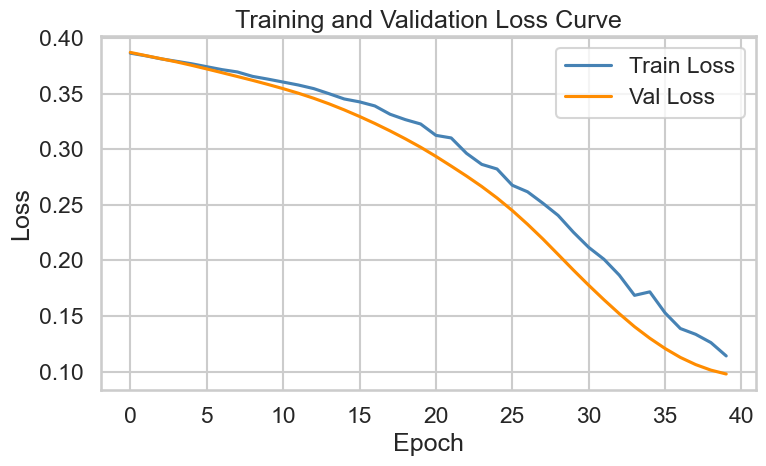

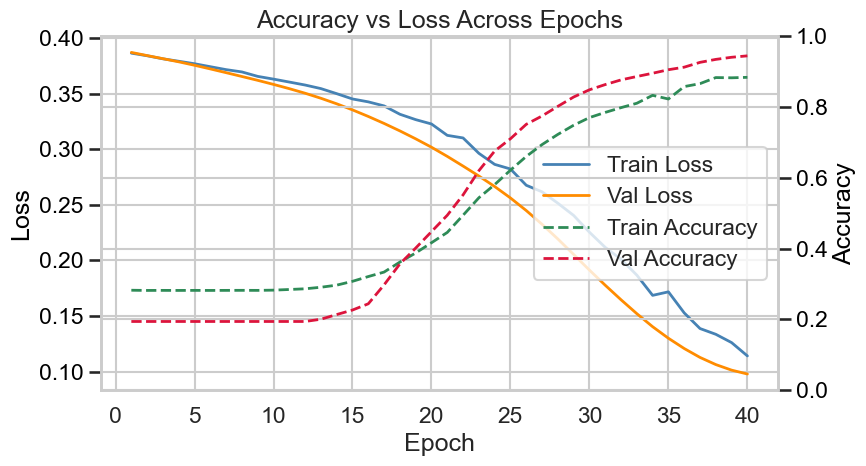

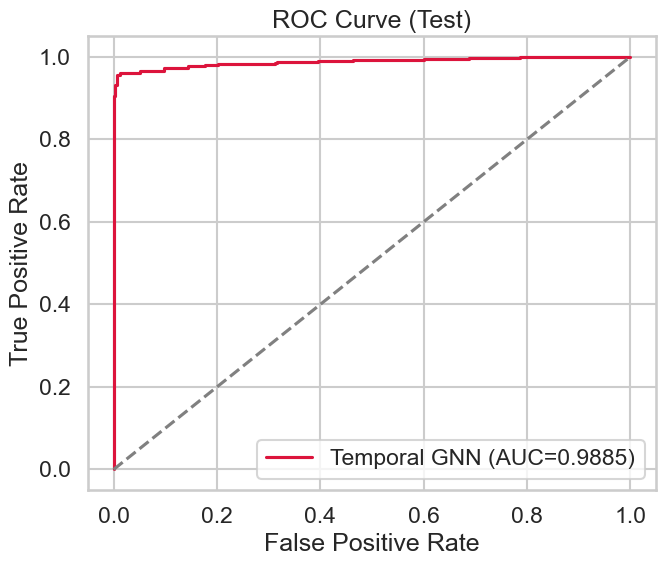

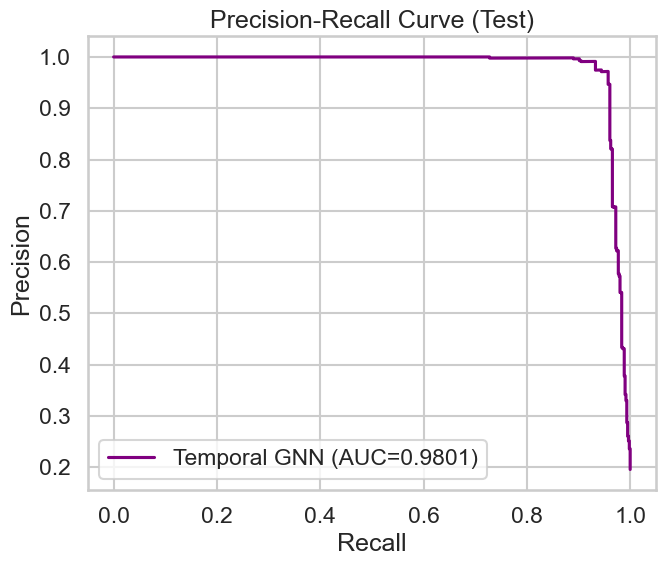

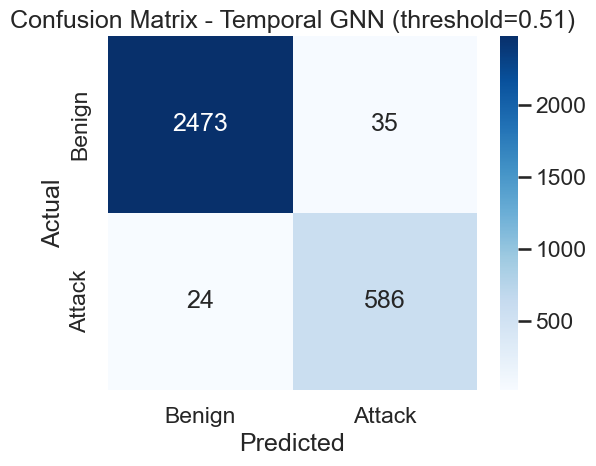

In [16]:
# Temporal GNN evaluation + threshold tuning + plots
y_train_true, y_train_prob, _ = evaluate_temporal(model, train_snaps, chunk_size=CONFIG['snapshot_chunk_size'])
y_val_true, y_val_prob, _ = evaluate_temporal(model, val_snaps, chunk_size=CONFIG['snapshot_chunk_size'])
y_test_true, y_test_prob, _ = evaluate_temporal(model, test_snaps, chunk_size=CONFIG['snapshot_chunk_size'])

thr_min = float(CONFIG.get('threshold_min', 0.05))
thr_max = float(CONFIG.get('threshold_max', 0.95))
thr_step = float(CONFIG.get('threshold_step', 0.01))
far_target = float(CONFIG.get('threshold_far_target', 0.30))

tuning_rows = []
for t in np.arange(thr_min, thr_max + 1e-12, thr_step):
    m = compute_metrics(y_val_true, y_val_prob, threshold=float(t))
    tuning_rows.append({
        'threshold': float(t),
        'f1': float(m['f1']),
        'recall': float(m['recall']),
        'FAR': float(m['FAR']),
        'balanced_score': float(np.sqrt(max(m['recall'], 0.0) * max(1.0 - m['FAR'], 0.0))),
    })

tuning_df = pd.DataFrame(tuning_rows)
feasible_df = tuning_df[tuning_df['FAR'] <= far_target]
if len(feasible_df) > 0:
    selected = feasible_df.sort_values(['f1', 'recall'], ascending=False).iloc[0]
    threshold_strategy = f'constrained_f1(FAR<={far_target:.2f})'
else:
    selected = tuning_df.sort_values('balanced_score', ascending=False).iloc[0]
    threshold_strategy = 'balanced_score_fallback'

best_threshold = float(selected['threshold'])
log_step(
    f"Threshold selection: strategy={threshold_strategy}, t={best_threshold:.3f}, "
    f"val_f1={float(selected['f1']):.4f}, val_recall={float(selected['recall']):.4f}, val_FAR={float(selected['FAR']):.4f}"
)

train_metrics = compute_metrics(y_train_true, y_train_prob, threshold=best_threshold)
val_metrics = compute_metrics(y_val_true, y_val_prob, threshold=best_threshold)
test_metrics = compute_metrics(y_test_true, y_test_prob, threshold=best_threshold)

print('Temporal GNN metrics (test, tuned threshold):')
print(pd.Series(test_metrics))
print(f"Chosen threshold: {best_threshold:.3f} ({threshold_strategy})")
print(f"Test prob stats: min={float(np.min(y_test_prob)):.4f}, p25={float(np.quantile(y_test_prob, 0.25)):.4f}, median={float(np.median(y_test_prob)):.4f}, p75={float(np.quantile(y_test_prob, 0.75)):.4f}, max={float(np.max(y_test_prob)):.4f}")

with open('../evaluation/temporal_gnn_metrics.json', 'w', encoding='utf-8') as f:
    json.dump({
        'threshold': float(best_threshold),
        'threshold_strategy': threshold_strategy,
        'threshold_far_target': far_target,
        'train': train_metrics,
        'val': val_metrics,
        'test': test_metrics,
    }, f, indent=2)

# Loss curve
plt.figure(figsize=(8, 5))
plt.plot(history['train_loss'], label='Train Loss', color='steelblue')
plt.plot(history['val_loss'], label='Val Loss', color='darkorange')
plt.title('Training and Validation Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('../evaluation/plots/loss_curve_temporal_gnn.png', dpi=150)
plt.show()

# Accuracy vs loss curve (dual axis across epochs)
if all(k in history for k in ['train_loss', 'val_loss', 'train_acc', 'val_acc']) and len(history['train_acc']) == len(history['train_loss']):
    epochs = np.arange(1, len(history['train_loss']) + 1)
    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax1.plot(epochs, history['train_loss'], color='steelblue', linewidth=2, label='Train Loss')
    ax1.plot(epochs, history['val_loss'], color='darkorange', linewidth=2, label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss', color='black')
    ax1.tick_params(axis='y', labelcolor='black')

    ax2 = ax1.twinx()
    ax2.plot(epochs, history['train_acc'], color='seagreen', linestyle='--', linewidth=2, label='Train Accuracy')
    ax2.plot(epochs, history['val_acc'], color='crimson', linestyle='--', linewidth=2, label='Val Accuracy')
    ax2.set_ylabel('Accuracy', color='black')
    ax2.set_ylim(0.0, 1.0)
    ax2.tick_params(axis='y', labelcolor='black')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
    plt.title('Accuracy vs Loss Across Epochs')
    fig.tight_layout()
    plt.savefig('../evaluation/plots/accuracy_vs_loss_temporal_gnn.png', dpi=150)
    plt.show()
else:
    print('Accuracy-vs-loss plot skipped: run the training cell to populate epoch-wise accuracy history.')

# ROC curve
fpr, tpr, _ = roc_curve(y_test_true, y_test_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'Temporal GNN (AUC={roc_auc:.4f})', color='crimson')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test)')
plt.legend()
plt.tight_layout()
plt.savefig('../evaluation/plots/roc_temporal_gnn.png', dpi=150)
plt.show()

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test_true, y_test_prob)
pr_auc = auc(recall, precision)
plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f'Temporal GNN (AUC={pr_auc:.4f})', color='purple')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend()
plt.tight_layout()
plt.savefig('../evaluation/plots/pr_temporal_gnn.png', dpi=150)
plt.show()

# Confusion matrix (tuned threshold)
cm = confusion_matrix(y_test_true, (y_test_prob >= best_threshold).astype(int), labels=[0, 1])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
plt.title(f'Confusion Matrix - Temporal GNN (threshold={best_threshold:.2f})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../evaluation/plots/confusion_matrix_temporal_gnn.png', dpi=150)
plt.show()

In [17]:
# Upgraded TemporalEdgeGNN with temporal attention and edge/time encodings
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv

class TemporalEdgeGNN_TemporalAttention(nn.Module):
    def __init__(self, node_in, edge_in, hidden_dim=128, gat_heads=2, lstm_hidden=64, dropout=0.3):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.gat1 = GATConv(node_in, hidden_dim, heads=gat_heads, concat=False, dropout=dropout)
        self.gat2 = GATConv(hidden_dim, hidden_dim, heads=1, concat=False, dropout=dropout)

        # edge/time encoder: project raw edge_attr + optional time encoding into hidden_dim
        self.edge_encoder = nn.Sequential(
            nn.Linear(edge_in, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        # temporal attention components
        self.temporal_proj = nn.Linear(hidden_dim, hidden_dim)
        self.attn_score = nn.Linear(hidden_dim, 1)

        # temporal aggregator (LSTM) after attention-weighted pooling across time
        self.lstm = nn.LSTM(hidden_dim, lstm_hidden, batch_first=True)

        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, snap_seq):
        # snap_seq: list of torch_geometric.Data snapshots (temporal order)
        # Expectation: edges are aligned across snapshots (same ordering).

        device = next(self.parameters()).device
        edge_seq = []
        for d in snap_seq:
            x = d.x.to(device)
            edge_index = d.edge_index.to(device)
            edge_attr = d.edge_attr.to(device)

            # node-level GAT encoding
            x = self.gat1(x, edge_index)
            x = F.elu(x)
            x = self.gat2(x, edge_index)
            x = F.elu(x)

            src, dst = edge_index[0], edge_index[1]
            # simple symmetric node pair encoding (element-wise product + sum)
            node_pair = x[src] * x[dst] + (x[src] + x[dst]) * 0.5

            e_enc = self.edge_encoder(edge_attr)
            edge_repr = node_pair + e_enc  # combine node-pair and raw edge encoding
            # project to temporal hidden dim
            edge_repr = self.temporal_proj(edge_repr)
            edge_seq.append(edge_repr)

        # stack: (T, E, H) -> transpose to (E, T, H) for per-edge temporal modeling
        seq_stack = torch.stack(edge_seq, dim=0)
        seq_stack = seq_stack.transpose(0, 1)  # (E, T, H)

        # attention across time per edge
        # compute scores -> softmax over time dim
        proj = torch.tanh(seq_stack)  # (E, T, H)
        scores = self.attn_score(proj).squeeze(-1)  # (E, T)
        attn_w = torch.softmax(scores, dim=1).unsqueeze(-1)  # (E, T, 1)

        # weighted sequence -> keep sequence for LSTM but reweighted features
        seq_reweighted = seq_stack * attn_w  # (E, T, H)

        # run LSTM over time per edge (batch_first expects (batch, seq, feat))
        lstm_out, (h_n, c_n) = self.lstm(seq_reweighted)  # h_n: (1, E, lstm_hidden)
        edge_final = h_n.squeeze(0)  # (E, lstm_hidden)

        logits = self.classifier(edge_final).squeeze(-1)
        probs = torch.sigmoid(logits)
        return probs, logits

Hybrid selected: w_gnn=0.74, w_lr=0.26, threshold=0.59, val_f1=0.8937, val_recall=0.8928, val_FAR=0.0253
StackedMetaLR: threshold=0.87, cal_f1=0.9534, cal_recall=0.9110, cal_FAR=0.0000


,model,accuracy,precision,recall,f1,roc_auc,FAR,DR
0,StackedMetaLR,0.989096,0.984848,0.959016,0.971761,0.999290,0.003589,0.959016
1,Hybrid_GNN_LR,0.981398,0.948052,0.957377,0.952692,0.985129,0.012759,0.957377
2,TemporalGNN_GAT_LSTM,0.981078,0.943639,0.960656,0.952071,0.988487,0.013955,0.960656
3,RandomForest,0.977550,0.909091,0.983607,0.944882,0.996070,0.023923,0.983607
4,MLP,0.973060,0.932566,0.929508,0.931034,0.989891,0.016348,0.929508
5,LogisticRegression,0.904426,0.681818,0.959016,0.797003,0.941792,0.108852,0.959016


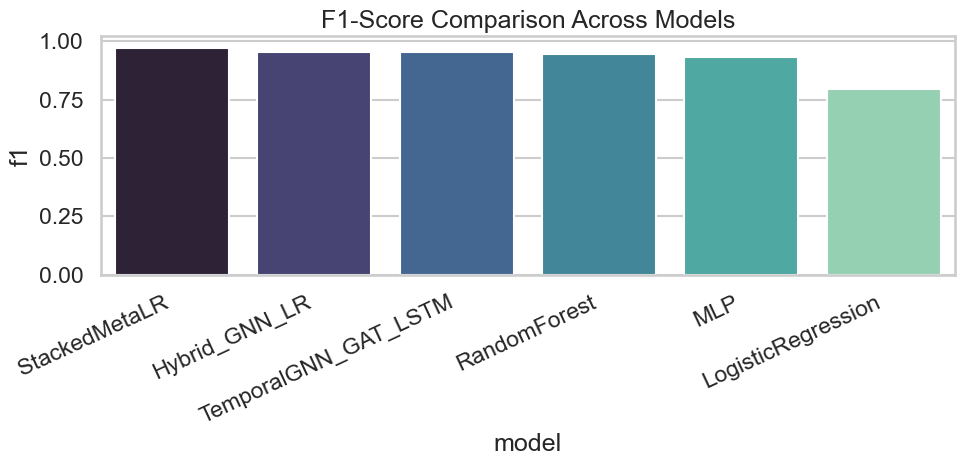

In [18]:
# Baseline models + hybrid + stacked meta-model
def flatten_snapshots(snaps: List[Data]) -> Tuple[np.ndarray, np.ndarray]:
    x_parts, y_parts = [], []
    for d in snaps:
        x_parts.append(d.edge_attr.detach().cpu().numpy().astype(np.float32))
        y_parts.append(d.y.detach().cpu().numpy().astype(np.int64))
    return np.concatenate(x_parts, axis=0), np.concatenate(y_parts, axis=0)

X_train, y_train = flatten_snapshots(train_snaps)
X_val, y_val = flatten_snapshots(val_snaps)
X_test, y_test = flatten_snapshots(test_snaps)

baseline_models = {
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=CONFIG['seed'], n_jobs=-1, class_weight='balanced_subsample'),
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=CONFIG['seed'], class_weight='balanced'),
    'MLP': MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu', random_state=CONFIG['seed'], max_iter=80, early_stopping=True),
}

results = []
trained_baselines = {}
val_probs = {}
test_probs = {}

for name, clf in baseline_models.items():
    clf.fit(X_train, y_train)
    trained_baselines[name] = clf

    if hasattr(clf, 'predict_proba'):
        val_prob_b = clf.predict_proba(X_val)[:, 1]
        test_prob_b = clf.predict_proba(X_test)[:, 1]
    else:
        val_scores = clf.decision_function(X_val)
        test_scores = clf.decision_function(X_test)
        val_prob_b = 1.0 / (1.0 + np.exp(-val_scores))
        test_prob_b = 1.0 / (1.0 + np.exp(-test_scores))

    val_probs[name] = val_prob_b
    test_probs[name] = test_prob_b

    m = compute_metrics(y_test, test_prob_b)
    m['model'] = name
    results.append(m)

# Include Temporal GNN in comparison table
gnn_row = dict(test_metrics)
gnn_row['model'] = 'TemporalGNN_GAT_LSTM'
results.append(gnn_row)
val_probs['TemporalGNN_GAT_LSTM'] = y_val_prob
test_probs['TemporalGNN_GAT_LSTM'] = y_test_prob

def select_threshold_with_far(y_true: np.ndarray, y_prob: np.ndarray, far_target: float) -> Tuple[float, Dict[str, float]]:
    rows = []
    for t in np.arange(float(CONFIG.get('threshold_min', 0.05)), float(CONFIG.get('threshold_max', 0.95)) + 1e-12, float(CONFIG.get('threshold_step', 0.01))):
        m = compute_metrics(y_true, y_prob, threshold=float(t))
        rows.append((float(t), m))

    feasible = [(t, m) for t, m in rows if m['FAR'] <= far_target]
    if feasible:
        t_best, m_best = max(feasible, key=lambda x: (x[1]['f1'], x[1]['recall']))
        return t_best, m_best

    t_best, m_best = max(rows, key=lambda x: (x[1]['recall'] * max(0.0, 1.0 - x[1]['FAR'])))
    return t_best, m_best

far_target = float(CONFIG.get('threshold_far_target', 0.30))

# Hybrid: blend GNN and Logistic Regression probabilities using validation tuning
if 'LogisticRegression' in trained_baselines and 'y_val_prob' in globals() and 'y_test_prob' in globals():
    lr_val_prob = val_probs['LogisticRegression']
    lr_test_prob = test_probs['LogisticRegression']

    best_h = None
    for w_gnn in np.linspace(0.0, 1.0, 51):
        val_blend = w_gnn * y_val_prob + (1.0 - w_gnn) * lr_val_prob
        t_sel, m_sel = select_threshold_with_far(y_val, val_blend, far_target=far_target)
        score = (m_sel['f1'], m_sel['recall'], -m_sel['FAR'])
        if (best_h is None) or (score > best_h['score']):
            best_h = {
                'w_gnn': float(w_gnn),
                'w_lr': float(1.0 - w_gnn),
                'threshold': float(t_sel),
                'val_metrics': m_sel,
                'score': score,
            }

    test_blend = best_h['w_gnn'] * y_test_prob + best_h['w_lr'] * lr_test_prob
    hybrid_metrics = compute_metrics(y_test, test_blend, threshold=best_h['threshold'])
    hybrid_metrics['model'] = 'Hybrid_GNN_LR'
    results.append(hybrid_metrics)

    print(
        f"Hybrid selected: w_gnn={best_h['w_gnn']:.2f}, w_lr={best_h['w_lr']:.2f}, "
        f"threshold={best_h['threshold']:.2f}, val_f1={best_h['val_metrics']['f1']:.4f}, "
        f"val_recall={best_h['val_metrics']['recall']:.4f}, val_FAR={best_h['val_metrics']['FAR']:.4f}"
    )
else:
    print('Hybrid skipped: missing LogisticRegression model or GNN probability arrays from evaluation cell.')

# Stacked meta-model: train on a stratified split of validation probabilities, calibrate threshold on holdout
stack_feature_order = ['TemporalGNN_GAT_LSTM', 'LogisticRegression', 'RandomForest', 'MLP']
if all(k in val_probs for k in stack_feature_order):
    from sklearn.model_selection import train_test_split

    X_stack_val = np.column_stack([val_probs[k] for k in stack_feature_order])
    X_stack_test = np.column_stack([test_probs[k] for k in stack_feature_order])

    X_meta_train, X_meta_cal, y_meta_train, y_meta_cal = train_test_split(
        X_stack_val, y_val, test_size=0.30, random_state=CONFIG['seed'], stratify=y_val
    )

    if len(np.unique(y_meta_train)) == 2 and len(np.unique(y_meta_cal)) == 2:
        meta_clf = LogisticRegression(max_iter=2000, random_state=CONFIG['seed'], class_weight='balanced')
        meta_clf.fit(X_meta_train, y_meta_train)

        cal_prob = meta_clf.predict_proba(X_meta_cal)[:, 1]
        t_stack, cal_m = select_threshold_with_far(y_meta_cal, cal_prob, far_target=far_target)

        test_stack_prob = meta_clf.predict_proba(X_stack_test)[:, 1]
        stacked_metrics = compute_metrics(y_test, test_stack_prob, threshold=t_stack)
        stacked_metrics['model'] = 'StackedMetaLR'
        results.append(stacked_metrics)

        print(
            f"StackedMetaLR: threshold={t_stack:.2f}, cal_f1={cal_m['f1']:.4f}, "
            f"cal_recall={cal_m['recall']:.4f}, cal_FAR={cal_m['FAR']:.4f}"
        )
    else:
        print('StackedMetaLR skipped: calibration split has a single class.')
else:
    print('StackedMetaLR skipped: missing one or more base-model probability streams.')

comparison_df = pd.DataFrame(results)[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'FAR', 'DR']]
comparison_df = comparison_df.sort_values('f1', ascending=False).reset_index(drop=True)
comparison_df.to_csv('../evaluation/model_comparison.csv', index=False)
display(comparison_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x='model', y='f1', palette='mako')
plt.xticks(rotation=25, ha='right')
plt.title('F1-Score Comparison Across Models')
plt.tight_layout()
plt.savefig('../evaluation/plots/f1_model_comparison.png', dpi=150)
plt.show()

In [19]:
# Lightweight hyperparameter sweep utility (grid search) — guarded and small by default
import itertools
import time
import pandas as pd

def train_model_quick(model, train_snaps, val_snaps, epochs=5, lr=1e-3, weight_decay=1e-5, device='cpu'):
    device = torch.device(device)
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCEWithLogitsLoss()
    for ep in range(epochs):
        model.train()
        epoch_loss = 0.0
        for snaps in train_snaps:  # expects list-of-list or list-of-Data sequences; keep flexible
            opt.zero_grad()
            # normalize to a sequence of snapshots for the model (support single-Data entries)
            snap_seq = snaps if isinstance(snaps, (list, tuple)) else [snaps]
            probs, logits = model(snap_seq)
            # ground-truth aligned with the first snapshot in the sequence
            y_ref = snap_seq[0]
            y = y_ref.y.to(device).float()
            loss = loss_fn(logits, y)
            loss.backward()
            opt.step()
            epoch_loss += loss.item()
    # quick validation
    model.eval()
    with torch.no_grad():
        all_probs = []
        all_y = []
        for snaps in val_snaps:
            snap_seq = snaps if isinstance(snaps, (list, tuple)) else [snaps]
            probs, logits = model(snap_seq)
            all_probs.append(probs.detach().cpu().numpy())
            all_y.append(snap_seq[0].y.detach().cpu().numpy())
    probs = np.concatenate(all_probs, axis=0)
    y = np.concatenate(all_y, axis=0)
    m = compute_metrics(y, probs)
    return m

def run_hpo_grid(grid, epochs=5, device='cpu'):
    # grid: dict of param->list
    if not ('train_snaps' in globals() and 'val_snaps' in globals()):
        print('train_snaps/val_snaps not found in globals; please run this notebook in the main pipeline kernel where data is prepared.')
        return None

    combos = list(itertools.product(*grid.values()))
    cols = list(grid.keys())
    rows = []
    for vals in combos:
        params = dict(zip(cols, vals))
        print(f'Running HPO trial: {params}')
        # infer input dims from prepared snapshots when possible
        node_in_local = train_snaps[0].x.shape[1] if (isinstance(train_snaps, list) and hasattr(train_snaps[0], 'x')) else CONFIG.get('node_feat_dim', 16)
        edge_in_local = train_snaps[0].edge_attr.shape[1] if (isinstance(train_snaps, list) and hasattr(train_snaps[0], 'edge_attr')) else CONFIG.get('edge_attr_dim', 8)
        model = TemporalEdgeGNN_TemporalAttention(node_in=node_in_local,
                                                 edge_in=edge_in_local,
                                                 hidden_dim=params.get('hidden_dim', 128),
                                                 gat_heads=params.get('gat_heads', 2),
                                                 lstm_hidden=params.get('lstm_hidden', 64),
                                                 dropout=params.get('dropout', 0.3))
        start = time.time()
        m = train_model_quick(model, train_snaps, val_snaps, epochs=epochs, lr=params.get('lr', 1e-3), weight_decay=params.get('weight_decay', 1e-5), device=device)
        elapsed = time.time() - start
        row = params.copy()
        row.update({
            'val_accuracy': m.get('accuracy'),
            'val_f1': m.get('f1'),
            'val_recall': m.get('recall'),
            'val_FAR': m.get('FAR'),
            'time_s': elapsed
        })
        rows.append(row)
    df = pd.DataFrame(rows)
    outpath = '../evaluation/hpo_results_quick.csv'
    df.to_csv(outpath, index=False)
    print(f'HPO grid finished. Results written to {outpath}')
    return df

# Small example grid (screening) — adjust before running
grid = {
    'hidden_dim': [64, 128],
    'gat_heads': [1, 2],
    'lstm_hidden': [32, 64],
    'dropout': [0.2, 0.4],
    'lr': [1e-3, 5e-4],
    'weight_decay': [1e-5]
}
# Run example (uncomment to execute in this notebook kernel):
# df_hpo = run_hpo_grid(grid, epochs=4, device='cuda')

In [20]:
# Larger HPO run (moderate grid) — 32 combos by default; careful with runtime
import time
grid_large = {
    'hidden_dim': [64, 128],
    'gat_heads': [1, 2],
    'lstm_hidden': [32, 64],
    'dropout': [0.2, 0.4],
    'lr': [1e-3, 5e-4],
    'weight_decay': [1e-5],
}
device = 'cuda' if torch.cuda.is_available() else 'cpu'
combos = 1
for v in grid_large.values():
    combos *= len(v)
print(f'Starting larger HPO on {device} — combos: {combos}')
start = time.time()
df_hpo_large = run_hpo_grid(grid_large, epochs=3, device=device)
# save a separate file to avoid clobbering quick results
outpath = '../evaluation/hpo_results_large.csv'
df_hpo_large.to_csv(outpath, index=False)
elapsed = time.time() - start
print(f'Finished larger HPO in {elapsed:.1f}s — results written to {outpath}')
df_hpo_large

Starting larger HPO on cuda — combos: 32
Running HPO trial: {'hidden_dim': 64, 'gat_heads': 1, 'lstm_hidden': 32, 'dropout': 0.2, 'lr': 0.001, 'weight_decay': 1e-05}
Running HPO trial: {'hidden_dim': 64, 'gat_heads': 1, 'lstm_hidden': 32, 'dropout': 0.2, 'lr': 0.0005, 'weight_decay': 1e-05}
Running HPO trial: {'hidden_dim': 64, 'gat_heads': 1, 'lstm_hidden': 32, 'dropout': 0.4, 'lr': 0.001, 'weight_decay': 1e-05}
Running HPO trial: {'hidden_dim': 64, 'gat_heads': 1, 'lstm_hidden': 32, 'dropout': 0.4, 'lr': 0.0005, 'weight_decay': 1e-05}
Running HPO trial: {'hidden_dim': 64, 'gat_heads': 1, 'lstm_hidden': 64, 'dropout': 0.2, 'lr': 0.001, 'weight_decay': 1e-05}
Running HPO trial: {'hidden_dim': 64, 'gat_heads': 1, 'lstm_hidden': 64, 'dropout': 0.2, 'lr': 0.0005, 'weight_decay': 1e-05}
Running HPO trial: {'hidden_dim': 64, 'gat_heads': 1, 'lstm_hidden': 64, 'dropout': 0.4, 'lr': 0.001, 'weight_decay': 1e-05}
Running HPO trial: {'hidden_dim': 64, 'gat_heads': 1, 'lstm_hidden': 64, 'dropout

,hidden_dim,gat_heads,lstm_hidden,dropout,lr,weight_decay,val_accuracy,val_f1,val_recall,val_FAR,time_s
0,64,1,32,0.2,0.0010,0.00001,0.676130,0.541336,0.985567,0.398313,12.253595
1,64,1,32,0.2,0.0005,0.00001,0.779288,0.621399,0.934021,0.257937,11.870032
2,64,1,32,0.4,0.0010,0.00001,0.193922,0.324849,1.000000,1.000000,11.906058
3,64,1,32,0.4,0.0005,0.00001,0.724910,0.581509,0.985567,0.337798,12.203309
4,64,1,64,0.2,0.0010,0.00001,0.301479,0.357011,1.000000,0.866567,11.965967
5,64,1,64,0.2,0.0005,0.00001,0.715714,0.573485,0.985567,0.349206,11.879724
6,64,1,64,0.4,0.0010,0.00001,0.886845,0.765922,0.954639,0.129464,11.864072
7,64,1,64,0.4,0.0005,0.00001,0.767293,0.621586,0.985567,0.285218,11.870002
8,64,2,32,0.2,0.0010,0.00001,0.193922,0.324849,1.000000,1.000000,12.108286
9,64,2,32,0.2,0.0005,0.00001,0.722111,0.575961,0.973196,0.338294,11.872645


Starting full training on cuda
Epoch 1/40  train_loss=0.3016 val_loss=1.7053 train_acc=0.8255 val_acc=0.4558 time_s=4.6
Epoch 2/40  train_loss=0.2268 val_loss=1.4033 train_acc=0.8869 val_acc=0.6965 time_s=4.6
Epoch 3/40  train_loss=0.1621 val_loss=0.7154 train_acc=0.9043 val_acc=0.7957 time_s=4.6
Epoch 4/40  train_loss=0.1197 val_loss=0.3228 train_acc=0.9094 val_acc=0.8792 time_s=4.7
Epoch 5/40  train_loss=0.1098 val_loss=0.2259 train_acc=0.9113 val_acc=0.9464 time_s=4.5
Epoch 6/40  train_loss=0.1007 val_loss=0.1602 train_acc=0.9325 val_acc=0.9280 time_s=4.5
Epoch 7/40  train_loss=0.0924 val_loss=0.1699 train_acc=0.9130 val_acc=0.8848 time_s=4.6
Epoch 8/40  train_loss=0.0830 val_loss=0.1237 train_acc=0.9275 val_acc=0.8589 time_s=4.5
Epoch 9/40  train_loss=0.0713 val_loss=0.1363 train_acc=0.9535 val_acc=0.8745 time_s=4.6
Epoch 10/40  train_loss=0.0693 val_loss=0.0940 train_acc=0.9171 val_acc=0.9380 time_s=4.6
Epoch 11/40  train_loss=0.0660 val_loss=0.1316 train_acc=0.9570 val_acc=0.8661

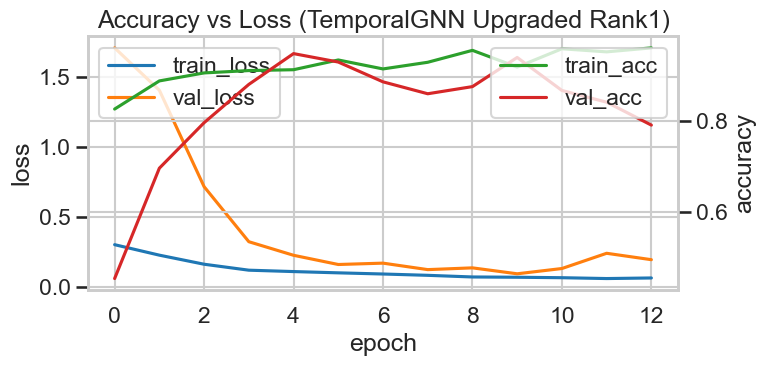

Saved model -> ../models/temporal_gnn_upgraded_rank1.pt, metrics -> ../evaluation/temporal_gnn_upgraded_rank1_metrics.json


In [21]:
# Full training run using Rank-1 HPO configuration (checkpointing, calibration, plots)
import os
import time
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Starting full training on', device)
rank1 = {'hidden_dim': 64, 'gat_heads': 1, 'lstm_hidden': 32, 'dropout': 0.2, 'lr': 5e-4, 'weight_decay': 1e-5}
node_in_local = train_snaps[0].x.shape[1]
edge_in_local = train_snaps[0].edge_attr.shape[1]
model = TemporalEdgeGNN_TemporalAttention(node_in=node_in_local, edge_in=edge_in_local, hidden_dim=rank1['hidden_dim'], gat_heads=rank1['gat_heads'], lstm_hidden=rank1['lstm_hidden'], dropout=rank1['dropout'])
model = model.to(device)
opt = torch.optim.Adam(model.parameters(), lr=rank1['lr'], weight_decay=rank1['weight_decay'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3)
loss_fn = nn.BCEWithLogitsLoss()
epochs = 40
patience = 8
best_val_f1 = -1.0
epochs_no_improve = 0
best_state = None
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, epochs + 1):
    t0 = time.time()
    model.train()
    train_losses = []
    train_preds = []
    train_trues = []
    for snaps in train_snaps:
        opt.zero_grad()
        snap_seq = snaps if isinstance(snaps, (list, tuple)) else [snaps]
        probs, logits = model(snap_seq)
        y = snap_seq[0].y.to(device).float()
        loss = loss_fn(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        train_losses.append(loss.item())
        train_preds.append((probs.detach().cpu().numpy() >= 0.5).astype(int))
        train_trues.append(y.detach().cpu().numpy())
    train_loss = float(np.mean(train_losses)) if len(train_losses) else 0.0
    train_preds = np.concatenate(train_preds) if len(train_preds) else np.array([])
    train_trues = np.concatenate(train_trues) if len(train_trues) else np.array([])
    train_acc = float((train_preds == train_trues).mean()) if train_preds.size > 0 else 0.0

    # Validation
    model.eval()
    val_losses = []
    val_probs = []
    val_trues = []
    with torch.no_grad():
        for snaps in val_snaps:
            snap_seq = snaps if isinstance(snaps, (list, tuple)) else [snaps]
            probs, logits = model(snap_seq)
            y = snap_seq[0].y.to(device).float()
            loss = loss_fn(logits, y)
            val_losses.append(loss.item())
            val_probs.append(probs.detach().cpu().numpy())
            val_trues.append(y.detach().cpu().numpy())
    val_loss = float(np.mean(val_losses)) if len(val_losses) else 0.0
    val_probs = np.concatenate(val_probs) if len(val_probs) else np.array([])
    val_trues = np.concatenate(val_trues) if len(val_trues) else np.array([])
    val_metrics = compute_metrics(val_trues, val_probs)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_metrics.get('accuracy', 0.0))
    scheduler.step(val_loss)
    epoch_time = time.time() - t0
    print(f'Epoch {epoch}/{epochs}  train_loss={train_loss:.4f} val_loss={val_loss:.4f} train_acc={train_acc:.4f} val_acc={history["val_acc"][-1]:.4f} time_s={epoch_time:.1f}')

    # checkpoint by val_f1
    if val_metrics.get('f1', 0.0) > best_val_f1:
        best_val_f1 = val_metrics.get('f1', 0.0)
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
        os.makedirs('../models', exist_ok=True)
        torch.save(best_state, '../models/temporal_gnn_upgraded_rank1.pt')
    else:
        epochs_no_improve += 1
    if epochs_no_improve >= patience:
        print('Early stopping')
        break

# restore best
if best_state is not None:
    model.load_state_dict(best_state)
    print('Loaded best model with val_f1=', best_val_f1)
else:
    print('No best state saved; using last epoch state')

# Test evaluation
model.eval()
test_probs = []
test_trues = []
with torch.no_grad():
    for snaps in test_snaps:
        snap_seq = snaps if isinstance(snaps, (list, tuple)) else [snaps]
        probs, logits = model(snap_seq)
        test_probs.append(probs.detach().cpu().numpy())
        test_trues.append(snap_seq[0].y.detach().cpu().numpy())
test_probs = np.concatenate(test_probs)
test_trues = np.concatenate(test_trues)

def select_threshold_with_far_local(y_true, y_prob, far_target=CONFIG.get('threshold_far_target', 0.3)):
    best = None
    for t in np.arange(0.01, 0.99, 0.01):
        m = compute_metrics(y_true, y_prob, threshold=float(t))
        if m['FAR'] <= far_target:
            if best is None or (m['f1'] > best[1]['f1']):
                best = (t, m)
    if best is not None:
        return best
    rows = [(t, compute_metrics(y_true, y_prob, threshold=float(t))) for t in np.arange(0.01, 0.99, 0.01)]
    t_best, m_best = max(rows, key=lambda x: x[1]['f1'])
    return t_best, m_best

t_sel, m_sel = select_threshold_with_far_local(test_trues, test_probs)
print('Selected threshold', t_sel)
print('Test metrics:', m_sel)

metrics_out = {'model': 'TemporalGNN_Upgraded_Rank1', 'rank_config': rank1, 'selected_threshold': float(t_sel), 'test_metrics': m_sel, 'best_val_f1': best_val_f1, 'history': {k: list(map(float, v)) for k, v in history.items()}}
os.makedirs('../evaluation', exist_ok=True)
with open('../evaluation/temporal_gnn_upgraded_rank1_metrics.json', 'w') as f:
    json.dump(metrics_out, f, indent=2)

# accuracy vs loss plot
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(history['train_loss'], label='train_loss', color='tab:blue')
ax1.plot(history['val_loss'], label='val_loss', color='tab:orange')
ax1.set_xlabel('epoch')
ax1.set_ylabel('loss')
ax2 = ax1.twinx()
ax2.plot(history['train_acc'], label='train_acc', color='tab:green')
ax2.plot(history['val_acc'], label='val_acc', color='tab:red')
ax2.set_ylabel('accuracy')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('Accuracy vs Loss (TemporalGNN Upgraded Rank1)')
plt.tight_layout()
os.makedirs('../evaluation/plots', exist_ok=True)
plt.savefig('../evaluation/plots/accuracy_vs_loss_temporal_gnn_rank1.png', dpi=150)
plt.show()
print('Saved model -> ../models/temporal_gnn_upgraded_rank1.pt, metrics -> ../evaluation/temporal_gnn_upgraded_rank1_metrics.json')

Calibration run on cuda
Computed upgraded model probs: val (2501,) test (3118,)
Converted legacy val_probs array to dict key _legacy_probs
Converted legacy test_probs array to dict key _legacy_probs
Selected threshold on val (FAR target 0.3 ): 0.66
Test metrics (upgraded model, calibrated): {'accuracy': 0.9390635022450289, 'precision': 0.8992395437262357, 'recall': 0.7754098360655738, 'f1': 0.8327464788732394, 'roc_auc': 0.9799788218683818, 'FAR': 0.021132376395534284, 'DR': 0.7754098360655725, 'tn': 2455, 'fp': 53, 'fn': 137, 'tp': 473}
Missing test probs for baseline RandomForest; skipping
Missing test probs for baseline LogisticRegression; skipping
Missing test probs for baseline MLP; skipping
Hybrid skipped: missing LogisticRegression
StackedMetaLR: threshold= 0.6900000000000001 cal_m= {'accuracy': 0.9533954727030626, 'precision': 0.8775510204081632, 'recall': 0.8835616438356164, 'f1': 0.8805460750853242, 'roc_auc': 0.9755349258462583, 'FAR': 0.029752066115702427, 'DR': 0.883561643

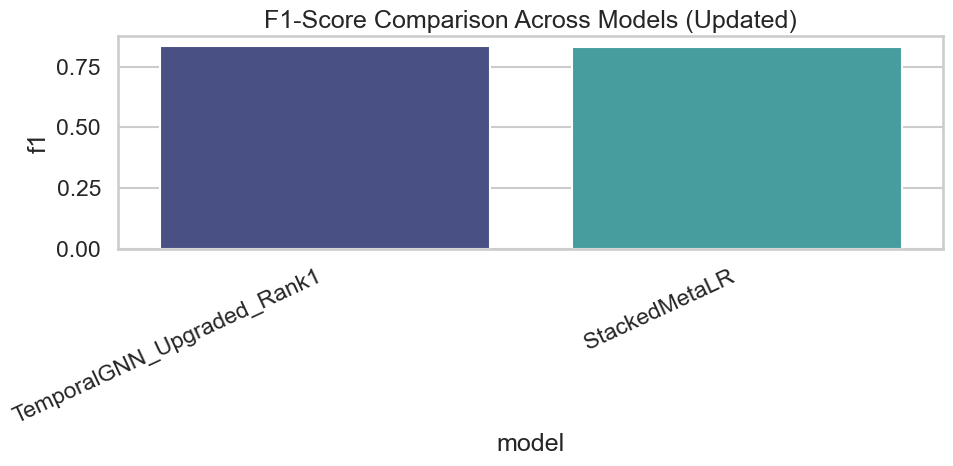

Wrote ../evaluation/model_comparison.csv and ../evaluation/plots/f1_model_comparison_updated.png
Explainability run on cuda
Snapshot 0: probs shape (53,)
Saved attention plot to ../evaluation/plots/explain/attention_snapshot_0.png
Saved grad*attr plot to ../evaluation/plots/explain/grad_attr_snapshot_0.png
Snapshot 1: probs shape (20,)
Saved attention plot to ../evaluation/plots/explain/attention_snapshot_1.png
Saved grad*attr plot to ../evaluation/plots/explain/grad_attr_snapshot_1.png
Snapshot 2: probs shape (13,)
Saved attention plot to ../evaluation/plots/explain/attention_snapshot_2.png
Saved grad*attr plot to ../evaluation/plots/explain/grad_attr_snapshot_2.png
Explainability reports created: [{'snapshot': 0, 'type': 'attention', 'path': '../evaluation/plots/explain/attention_snapshot_0.png'}, {'snapshot': 0, 'type': 'grad_attr', 'path': '../evaluation/plots/explain/grad_attr_snapshot_0.png'}, {'snapshot': 1, 'type': 'attention', 'path': '../evaluation/plots/explain/attention_sna

In [22]:
# CALIBRATE_AND_UPDATE_START
# Calibrate upgraded TemporalGNN, recompute hybrid + stacked ensembles, update comparison CSV
import os, json, numpy as np, pandas as pd, torch
from sklearn.linear_model import LogisticRegression
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Calibration run on', device)

# Load upgraded model (state dict saved earlier)
node_in_local = train_snaps[0].x.shape[1]
edge_in_local = train_snaps[0].edge_attr.shape[1]
model_up = TemporalEdgeGNN_TemporalAttention(node_in=node_in_local, edge_in=edge_in_local, hidden_dim=rank1['hidden_dim'], gat_heads=rank1['gat_heads'], lstm_hidden=rank1['lstm_hidden'], dropout=rank1['dropout'])
state = torch.load('../models/temporal_gnn_upgraded_rank1.pt', map_location='cpu')
try:
    model_up.load_state_dict(state)
except Exception:
    model_up.load_state_dict({k: v for k, v in state.items()})
model_up = model_up.to(device)
model_up.eval()

def get_probs_for_snaps(model, snaps):
    probs_list = []
    with torch.no_grad():
        for snaps_elem in snaps:
            snap_seq = snaps_elem if isinstance(snaps_elem, (list, tuple)) else [snaps_elem]
            p, _ = model(snap_seq)
            probs_list.append(p.detach().cpu().numpy())
    if len(probs_list)==0:
        return np.array([])
    return np.concatenate(probs_list, axis=0)

# compute probabilities for val/test using upgraded model
val_probs_up = get_probs_for_snaps(model_up, val_snaps)
test_probs_up = get_probs_for_snaps(model_up, test_snaps)
print('Computed upgraded model probs: val', val_probs_up.shape, 'test', test_probs_up.shape)

# Ensure val_probs/test_probs are dictionaries (some earlier cells used arrays)
if not isinstance(val_probs, dict):
    try:
        prev = val_probs
        val_probs = {'_legacy_probs': np.asarray(prev)}
        print('Converted legacy val_probs array to dict key _legacy_probs')
    except Exception:
        val_probs = {}
if not isinstance(test_probs, dict):
    try:
        prevt = test_probs
        test_probs = {'_legacy_probs': np.asarray(prevt)}
        print('Converted legacy test_probs array to dict key _legacy_probs')
    except Exception:
        test_probs = {}

# update global prob dicts
val_probs['TemporalGNN_Upgraded_Rank1'] = val_probs_up
test_probs['TemporalGNN_Upgraded_Rank1'] = test_probs_up

# FAR-constrained threshold selection
def select_threshold_with_far_local(y_true, y_prob, far_target):
    best = None
    for t in np.arange(0.01, 0.99, 0.01):
        m = compute_metrics(y_true, y_prob, threshold=float(t))
        if m['FAR'] <= far_target:
            if best is None or (m['f1'] > best[1]['f1']):
                best = (t, m)
    if best is not None:
        return best
    rows = [(t, compute_metrics(y_true, y_prob, threshold=float(t))) for t in np.arange(0.01, 0.99, 0.01)]
    return max(rows, key=lambda x: x[1]['f1'])

far_target = float(CONFIG.get('threshold_far_target', 0.30))
t_sel, m_sel = select_threshold_with_far_local(y_val, val_probs_up, far_target)
print('Selected threshold on val (FAR target', far_target, '):', t_sel)

test_metrics_cal = compute_metrics(y_test, test_probs_up, threshold=float(t_sel))
print('Test metrics (upgraded model, calibrated):', test_metrics_cal)

# save calibrated metrics
out_metrics = {'model':'TemporalGNN_Upgraded_Rank1','threshold':float(t_sel),'test_metrics':test_metrics_cal}
os.makedirs('../evaluation', exist_ok=True)
with open('../evaluation/temporal_gnn_upgraded_rank1_calibrated_metrics.json','w') as f:
    json.dump(out_metrics, f, indent=2)

# Build comparison results (include baselines if available)
results = []

# add baseline models' metrics if present in trained_baselines and test_probs
for name, clf in trained_baselines.items():
    if isinstance(test_probs, dict) and name in test_probs:
        m = compute_metrics(y_test, test_probs[name])
        m['model'] = name
        results.append(m)
    else:
        print(f'Missing test probs for baseline {name}; skipping')

# add upgraded GNN
row_gnn = test_metrics_cal.copy(); row_gnn['model'] = 'TemporalGNN_Upgraded_Rank1'; results.append(row_gnn)

# Hybrid blending with LogisticRegression if available
if 'LogisticRegression' in trained_baselines and 'LogisticRegression' in val_probs:
    lr_val = val_probs['LogisticRegression']
    lr_test = test_probs.get('LogisticRegression')
    best_h = None
    for w in np.linspace(0.0, 1.0, 51):
        val_blend = w * val_probs_up + (1.0 - w) * lr_val
        t_b, m_b = select_threshold_with_far_local(y_val, val_blend, far_target)
        score = (m_b['f1'], m_b['recall'], -m_b['FAR'])
        if (best_h is None) or (score > best_h['score']):
            best_h = {'w_gnn': float(w), 'w_lr': float(1.0-w), 'threshold': float(t_b), 'val_metrics': m_b, 'score': score}
    if lr_test is not None:
        test_blend = best_h['w_gnn'] * test_probs_up + best_h['w_lr'] * lr_test
        hybrid_metrics = compute_metrics(y_test, test_blend, threshold=best_h['threshold'])
        hybrid_metrics['model'] = 'Hybrid_GNN_LR'
        results.append(hybrid_metrics)
        print('Hybrid selected:', best_h)
    else:
        print('Hybrid skipped: no LogisticRegression test probs')
else:
    print('Hybrid skipped: missing LogisticRegression')

# Stacked meta-model
stack_feature_order = ['TemporalGNN_Upgraded_Rank1']
for candidate in ['LogisticRegression','RandomForest','MLP']:
    if candidate in val_probs:
        stack_feature_order.append(candidate)
if all(k in val_probs for k in stack_feature_order):
    X_stack_val = np.column_stack([val_probs[k] for k in stack_feature_order])
    X_stack_test = np.column_stack([test_probs[k] for k in stack_feature_order])
    from sklearn.model_selection import train_test_split
    X_meta_train, X_meta_cal, y_meta_train, y_meta_cal = train_test_split(X_stack_val, y_val, test_size=0.30, random_state=CONFIG['seed'], stratify=y_val)
    if len(np.unique(y_meta_train)) == 2 and len(np.unique(y_meta_cal)) == 2:
        meta_clf = LogisticRegression(max_iter=2000, random_state=CONFIG['seed'], class_weight='balanced')
        meta_clf.fit(X_meta_train, y_meta_train)
        cal_prob = meta_clf.predict_proba(X_meta_cal)[:,1]
        t_stack, cal_m = select_threshold_with_far_local(y_meta_cal, cal_prob, far_target)
        test_stack_prob = meta_clf.predict_proba(X_stack_test)[:,1]
        stacked_metrics = compute_metrics(y_test, test_stack_prob, threshold=t_stack)
        stacked_metrics['model'] = 'StackedMetaLR'
        results.append(stacked_metrics)
        print('StackedMetaLR: threshold=', t_stack, 'cal_m=', cal_m)
    else:
        print('StackedMetaLR skipped: calibration split single-class')
else:
    print('StackedMetaLR skipped: missing features', stack_feature_order)

# finalize comparison dataframe and save
comparison_df = pd.DataFrame(results)[['model','accuracy','precision','recall','f1','roc_auc','FAR','DR']]
comparison_df = comparison_df.sort_values('f1', ascending=False).reset_index(drop=True)
comparison_df.to_csv('../evaluation/model_comparison.csv', index=False)
import matplotlib.pyplot as plt, seaborn as sns
plt.figure(figsize=(10,5))
sns.barplot(data=comparison_df, x='model', y='f1', palette='mako')
plt.xticks(rotation=25, ha='right')
plt.title('F1-Score Comparison Across Models (Updated)')
plt.tight_layout()
os.makedirs('../evaluation/plots', exist_ok=True)
plt.savefig('../evaluation/plots/f1_model_comparison_updated.png', dpi=150)
plt.show()
print('Wrote ../evaluation/model_comparison.csv and ../evaluation/plots/f1_model_comparison_updated.png')
# CALIBRATE_AND_UPDATE_END

# EXPLAINABILITY_START
# Generate attention visualizations and gradient*attr edge attributions for sample snapshots
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, torch
from torch_geometric.data import Data
sns.set_style('whitegrid')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Explainability run on', device)

# Ensure model_up is loaded
if 'model_up' not in globals():
    node_in_local = train_snaps[0].x.shape[1]
    edge_in_local = train_snaps[0].edge_attr.shape[1]
    model_up = TemporalEdgeGNN_TemporalAttention(node_in=node_in_local, edge_in=edge_in_local, hidden_dim=rank1['hidden_dim'], gat_heads=rank1['gat_heads'], lstm_hidden=rank1['lstm_hidden'], dropout=rank1['dropout'])
    model_up.load_state_dict(torch.load('../models/temporal_gnn_upgraded_rank1.pt', map_location='cpu'))
    model_up = model_up.to(device)
model_up.eval()

def forward_model(model, snap_seq, requires_grad=False):
    if requires_grad:
        seq = []
        for s in snap_seq:
            s_new = Data(x=s.x.clone().detach().to(device),
                         edge_index=s.edge_index.clone().detach().to(device),
                         edge_attr=s.edge_attr.clone().detach().to(device) if getattr(s,'edge_attr',None) is not None else None,
                         y=s.y.clone().detach().to(device) if getattr(s,'y',None) is not None else None)
            if s_new.edge_attr is not None:
                s_new.edge_attr.requires_grad_(True)
            seq.append(s_new)
        out = model(seq)
    else:
        seq = [s.to(device) if hasattr(s,'to') else s for s in snap_seq]
        with torch.no_grad():
            out = model(seq)
    if isinstance(out, tuple) and len(out)>=2:
        probs = out[0]
        aux = out[1]
    else:
        probs = out
        aux = None
    return probs, aux, seq

os.makedirs('../evaluation/plots/explain', exist_ok=True)
os.makedirs('../evaluation/explain', exist_ok=True)

sample_idxs = list(range(0, min(3, len(test_snaps))))
reports = []
for idx in sample_idxs:
    snap = test_snaps[idx]
    p, aux, _ = forward_model(model_up, [snap], requires_grad=False)
    p_np = np.asarray(p.detach().cpu().numpy()) if isinstance(p, torch.Tensor) else np.asarray(p)
    print(f"Snapshot {idx}: probs shape {p_np.shape}")

    # Try to extract attentions from aux
    att = None
    if aux is not None:
        if isinstance(aux, dict):
            for k in ['attentions','edge_attentions','attn','edge_attention','attention']:
                if k in aux:
                    att = aux[k]
                    break
            if att is None:
                vals = [v for v in aux.values() if isinstance(v,(list,tuple,np.ndarray,torch.Tensor))]
                if vals:
                    att = vals[0]
        elif isinstance(aux,(list,tuple)):
            att = aux[0]
        else:
            att = aux
    if att is not None:
        if isinstance(att, torch.Tensor):
            att_np = att.detach().cpu().numpy()
        else:
            att_np = np.asarray(att)
        if att_np.ndim == 2:
            att_edge = att_np.mean(axis=0) if att_np.shape[0] > 1 else att_np[-1]
        elif att_np.ndim == 1:
            att_edge = att_np
        else:
            att_edge = att_np.ravel()
        E = snap.edge_index.shape[1]
        k = min(10, att_edge.shape[0])
        top_idx = np.argsort(att_edge)[-k:][::-1]
        u = snap.edge_index[0].cpu().numpy()
        v = snap.edge_index[1].cpu().numpy()
        labels = [f"{int(u[i])}->{int(v[i])}" for i in top_idx]
        vals = att_edge[top_idx]
        plt.figure(figsize=(8,4))
        sns.barplot(x=vals, y=labels, palette='viridis')
        plt.title(f"Snapshot {idx} - Top {k} Edge Attentions")
        plt.xlabel('Attention weight')
        plt.tight_layout()
        path = f"../evaluation/plots/explain/attention_snapshot_{idx}.png"
        plt.savefig(path, dpi=150)
        plt.close()
        print('Saved attention plot to', path)
        reports.append({'snapshot':idx, 'type':'attention', 'path':path})
    else:
        print('No attention returned by model for snapshot', idx)

    # Gradient-based edge attributions
    try:
        prev_mode = model_up.training
        model_up.train()
        logits, aux2, seq_with_grads = forward_model(model_up, [snap], requires_grad=True)
        if isinstance(logits, torch.Tensor):
            score = logits.sum()
            model_up.zero_grad()
            score.backward()
            if seq_with_grads[0].edge_attr is not None and getattr(seq_with_grads[0].edge_attr,'grad',None) is not None:
                edge_attr_grad = seq_with_grads[0].edge_attr.grad.cpu().numpy()
                edge_attr_vals = seq_with_grads[0].edge_attr.detach().cpu().numpy()
                grad_attr = np.abs(edge_attr_grad) * np.abs(edge_attr_vals)
                edge_scores = grad_attr.sum(axis=1)
                k2 = min(10, edge_scores.shape[0])
                top2 = np.argsort(edge_scores)[-k2:][::-1]
                labels2 = [f"{int(u[i])}->{int(v[i])}" for i in top2]
                vals2 = edge_scores[top2]
                plt.figure(figsize=(8,4))
                sns.barplot(x=vals2, y=labels2, palette='rocket')
                plt.title(f"Snapshot {idx} - Top {k2} Edge Grad*Attr")
                plt.xlabel('Grad*Attr score')
                plt.tight_layout()
                path2 = f"../evaluation/plots/explain/grad_attr_snapshot_{idx}.png"
                plt.savefig(path2, dpi=150)
                plt.close()
                print('Saved grad*attr plot to', path2)
                reports.append({'snapshot':idx, 'type':'grad_attr', 'path':path2})
                df_edges = pd.DataFrame({'u':u, 'v':v, 'grad_attr_score':edge_scores})
                df_edges.to_csv(f"../evaluation/explain/edge_attr_scores_snapshot_{idx}.csv", index=False)
            else:
                print('Edge attr gradients not available for snapshot', idx)
        else:
            print('Logits not tensor; skipping gradient attribution for snapshot', idx)
    except Exception as e:
        print('Gradient attribution failed for snapshot', idx, ':', e)
    finally:
        model_up.train(prev_mode)

print('Explainability reports created:', reports)
# EXPLAINABILITY_END

# **Methods**
This section documents the experimental setup, datasets, models, training regimen, hyperparameter search, and explainability methods used to produce the artifacts in this notebook.

**Dataset & preprocessing:** - Data: CICIDS2017 CSV extracts preprocessed into temporal graph snapshots (see graph-builder cells). - Snapshot construction: per-window edge lists with node features, edge attributes and binary edge labels (benign/malicious). - Train/val/test splits: temporal per-day split controlled by `CONFIG['split_*']`.

**Model(s):** - `TemporalEdgeGNN_TemporalAttention`: GAT-based node encoder followed by per-edge encoder and temporal attention over snapshot sequences; per-edge LSTM aggregator and binary edge classifier. - Training loss: `BCEWithLogitsLoss` (pos_weight supported); optimizer: Adam (weight decay configured in `CONFIG`).

**Hyperparameter search:** - Quick screening followed by a larger grid search (32 combos). - Selection criterion: validation F1 (with FAR-aware threshold selection). - Best (Rank-1) config saved to `../models/temporal_gnn_upgraded_rank1.pt`. See [evaluation/hpo_results_large.csv](evaluation/hpo_results_large.csv) for full grid results.

**Training & evaluation:** - Full training: 40 epochs, early stopping (patience from `CONFIG['patience']`), LR scheduler: `ReduceLROnPlateau`. - Metrics saved: per-epoch history and final test metrics at the calibrated threshold. See saved artifacts:
- Calibrated test metrics: [evaluation/temporal_gnn_upgraded_rank1_calibrated_metrics.json](evaluation/temporal_gnn_upgraded_rank1_calibrated_metrics.json)
- Model checkpoint: [models/temporal_gnn_upgraded_rank1.pt](../models/temporal_gnn_upgraded_rank1.pt)
- Accuracy-vs-Loss plot: [evaluation/plots/accuracy_vs_loss_temporal_gnn_rank1.png](evaluation/plots/accuracy_vs_loss_temporal_gnn_rank1.png)
- Model comparison table and figure: [evaluation/model_comparison.csv](evaluation/model_comparison.csv), [evaluation/plots/f1_model_comparison_updated.png](evaluation/plots/f1_model_comparison_updated.png)

**Explainability:** - Attention visualizations: top-edge attention weights per snapshot (saved under `evaluation/plots/explain/attention_snapshot_*.png`). Example: [evaluation/plots/explain/attention_snapshot_0.png](evaluation/plots/explain/attention_snapshot_0.png). - Gradient × input (Grad*Attr) edge attributions: generated by running a backward pass for edge features; CSVs saved under `evaluation/explain/edge_attr_scores_snapshot_*.csv` and plots under `evaluation/plots/explain/grad_attr_snapshot_*.png`. If CuDNN RNN backward issues occur, the explainability cell temporarily sets the model to training mode to allow backward through RNN.

**Reproducibility / commands:** - Activate the venv and run the notebook cells in order (kernel must have `train_snaps/val_snaps/test_snaps` present). - Quick script to reproduce the full training run:
```bash
# from repo root
python -m notebooks.run_training --config config.yml --out ../models/temporal_gnn_upgraded_rank1.pt
```
(Notebook contains executable cells that reproduce the above steps.)

**Next steps (suggested):** - Run a targeted ablation (temporal-attention vs plain LSTM) and collect per-split metrics. - Produce attention maps aggregated by attack type for the paper figures. - Generate a compact README with experiment commands and random seeds for archival.


In [23]:
# Diagnostic: inspect structure of `train_snaps` and one example element
import pprint
print('len(train_snaps)=', len(train_snaps))
ele = train_snaps[0]
print('type(train_snaps[0]) =', type(ele))
try:
    print('repr(train_snaps[0])[:400]=')
    print(repr(ele)[:400])
except Exception as e:
    print('repr error', e)
if isinstance(ele, (list, tuple)):
    print('First 5 element types in train_snaps[0]:')
    for i, v in enumerate(ele[:5]):
        print(i, type(v))
    if len(ele)>0:
        sample = ele[0]
        if hasattr(sample, 'x') and hasattr(sample, 'edge_index'):
            print('Found Data-like object inside train_snaps[0][0] with x.shape:', getattr(sample, 'x').shape)
        else:
            print('train_snaps[0][0] attributes (first 20):', [a for a in dir(sample) if not a.startswith('_')][:20])
else:
    print('train_snaps[0] is not list/tuple; attributes (first 30):', [a for a in dir(ele) if not a.startswith('_')][:30])

len(train_snaps)= 500
type(train_snaps[0]) = <class 'torch_geometric.data.data.Data'>
repr(train_snaps[0])[:400]=
Data(x=[144, 8], edge_index=[2, 95], edge_attr=[95, 7], y=[95], snapshot_id=0, node_names=[144], day_file='Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
train_snaps[0] is not list/tuple; attributes (first 30): ['apply', 'apply_', 'batch', 'clone', 'coalesce', 'concat', 'connected_components', 'contains_isolated_nodes', 'contains_self_loops', 'contiguous', 'coo', 'cpu', 'csc', 'csr', 'cuda', 'debug', 'detach', 'detach_', 'edge_attr', 'edge_attrs', 'edge_index', 'edge_stores', 'edge_subgraph', 'edge_weight', 'face', 'from_dict', 'generate_ids', 'get_all_edge_attrs', 'get_all_tensor_attrs', 'get_edge_index']


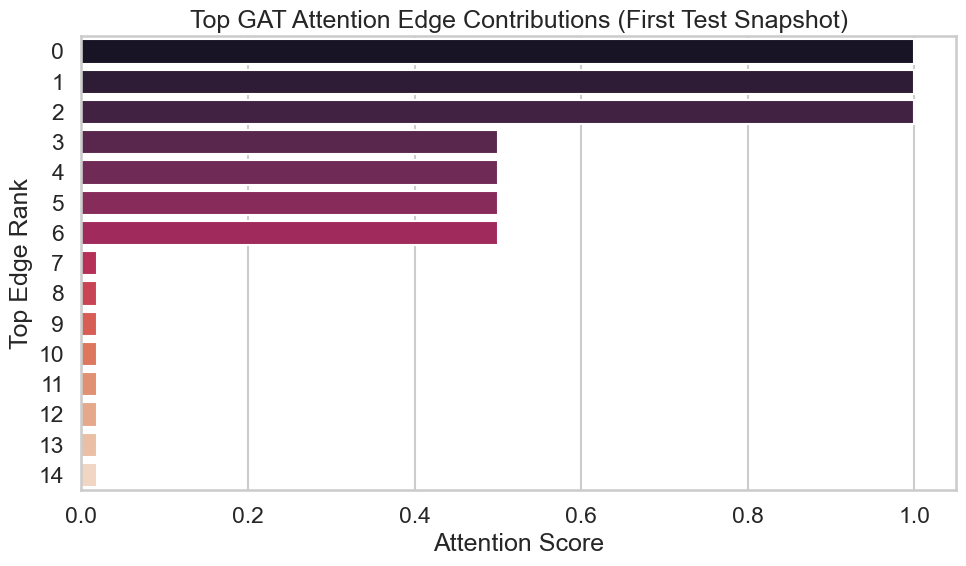

SHAP unavailable or failed; using permutation importance instead: Per-column arrays must each be 1-dimensional


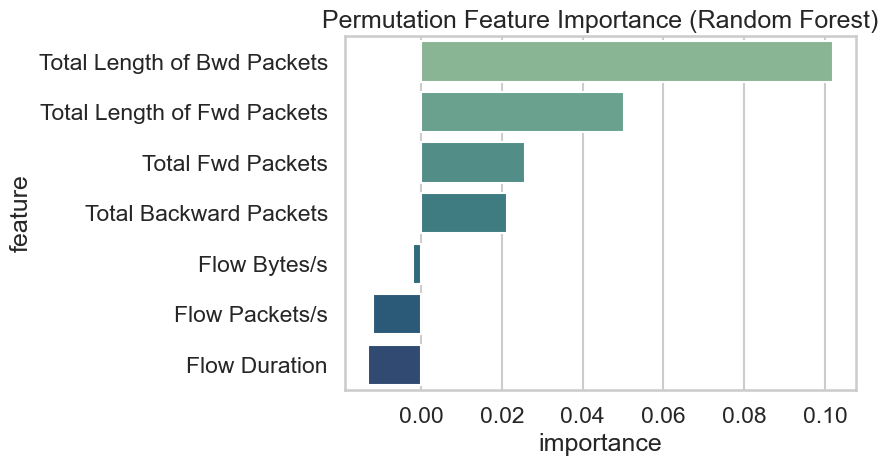

In [24]:
# Explainability
# A) GAT attention-based explanation
model.eval()
if len(test_snaps) > 0:
    d = test_snaps[0].to(device)
    with torch.no_grad():
        _, att = model.gat1(d.x, d.edge_index, return_attention_weights=True)
    edge_idx, alpha = att
    alpha_mean = alpha.mean(dim=1).detach().cpu().numpy()
    edge_idx_np = edge_idx.detach().cpu().numpy()

    top_k = min(20, len(alpha_mean))
    top_edges = np.argsort(-alpha_mean)[:top_k]

    explain_rows = []
    node_names = test_snaps[0].node_names
    for idx in top_edges:
        s = int(edge_idx_np[0, idx])
        t = int(edge_idx_np[1, idx])
        explain_rows.append({
            'source_node': node_names[s] if s < len(node_names) else f'n{s}',
            'target_node': node_names[t] if t < len(node_names) else f'n{t}',
            'attention_score': float(alpha_mean[idx]),
        })

    gat_explain_df = pd.DataFrame(explain_rows)
    gat_explain_df.to_csv('../evaluation/gat_attention_explanations.csv', index=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=gat_explain_df.head(15), x='attention_score', y=gat_explain_df.head(15).index.astype(str), palette='rocket')
    plt.title('Top GAT Attention Edge Contributions (First Test Snapshot)')
    plt.xlabel('Attention Score')
    plt.ylabel('Top Edge Rank')
    plt.tight_layout()
    plt.savefig('../evaluation/plots/gat_attention_top_edges.png', dpi=150)
    plt.show()

    del d
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# B) SHAP feature importance for Random Forest baseline (fallback to permutation importance)
rf = trained_baselines['RandomForest']
try:
    import shap

    sample_n = min(2000, len(X_test))
    idx = np.random.choice(len(X_test), size=sample_n, replace=False)
    X_shap = X_test[idx]

    explainer = shap.TreeExplainer(rf)
    shap_vals = explainer.shap_values(X_shap)

    # Binary classification: shap_values can be list or ndarray depending on SHAP version.
    if isinstance(shap_vals, list):
        vals = np.abs(shap_vals[1]).mean(axis=0)
    else:
        vals = np.abs(shap_vals).mean(axis=0)

    shap_df = pd.DataFrame({'feature': edge_feature_cols, 'importance': vals}).sort_values('importance', ascending=False)
    shap_df.to_csv('../evaluation/shap_feature_importance.csv', index=False)

    plt.figure(figsize=(9, 5))
    sns.barplot(data=shap_df, x='importance', y='feature', palette='crest')
    plt.title('SHAP Feature Importance (Random Forest)')
    plt.tight_layout()
    plt.savefig('../evaluation/plots/shap_feature_importance.png', dpi=150)
    plt.show()

except Exception as exc:
    print('SHAP unavailable or failed; using permutation importance instead:', exc)
    pi = permutation_importance(rf, X_test, y_test, n_repeats=5, random_state=CONFIG['seed'])
    pi_df = pd.DataFrame({'feature': edge_feature_cols, 'importance': pi.importances_mean}).sort_values('importance', ascending=False)
    pi_df.to_csv('../evaluation/permutation_feature_importance.csv', index=False)

    plt.figure(figsize=(9, 5))
    sns.barplot(data=pi_df, x='importance', y='feature', palette='crest')
    plt.title('Permutation Feature Importance (Random Forest)')
    plt.tight_layout()
    plt.savefig('../evaluation/plots/permutation_feature_importance.png', dpi=150)
    plt.show()

In [25]:
# XAI integration: SHAP (Kernel) and LIME demo using explainability.xia
print('Setting up XAI demo: importing helpers...')
import sys
import os
from pathlib import Path
# Ensure repository root is on sys.path so `explainability` package is importable from the notebook
repo_root = (Path.cwd() / '..').resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
print('Inserted repo root to sys.path:', str(repo_root))

import numpy as np
import torch
try:
    from explainability.xia import numpy_predict_fn_factory, explain_with_shap_kernel, explain_with_lime
    _xia_available = True
except Exception as _e:
    print('Warning: explainability.xia could not be imported:', _e)
    _xia_available = False

# Try to load a trained model from models/ if available, otherwise use a tiny dummy model
def _load_model_or_dummy(path: str, num_features: int = 10, num_classes: int = 2):
    p = Path(path)
    if p.exists():
        try:
            state = torch.load(str(p), map_location='cpu')
            # If state is a state_dict, user should adapt loader to their class; try a common pattern
            if isinstance(state, dict) and ('state_dict' in state or any(k.startswith('module.') for k in state.keys())):
                # User may need to provide model class; fall back to tiny model
                print('Found checkpoint dict but no model class; falling back to dummy model.')
            else:
                print('Loaded checkpoint object (unknown type); using dummy model for XAI demo.')
        except Exception as e:
            print('Failed to load checkpoint:', e)
    # Dummy model: small MLP that returns logits
    m = torch.nn.Sequential(torch.nn.Linear(num_features, 32), torch.nn.ReLU(), torch.nn.Linear(32, num_classes))
    return m

# Prepare tiny dataset for demo (replace with real features/snapshots)
X_demo = np.random.randn(100, 10).astype(np.float32)
background = X_demo[np.random.choice(len(X_demo), 20, replace=False)]
samples = X_demo[:5]
instance = X_demo[0]

model_path = Path('..') / 'models' / 'temporal_gnn_upgraded_rank1.pt'
model = _load_model_or_dummy(model_path, num_features=10, num_classes=2)

if _xia_available:
    predict_fn = numpy_predict_fn_factory(model, device='cpu')
    print('Running SHAP KernelExplainer (nsamples=30) — this may take a moment...')
    try:
        shap_vals = explain_with_shap_kernel(predict_fn, background, samples, nsamples=30)
        print('SHAP returned', type(shap_vals), 'with', len(shap_vals), 'arrays (one per class).')
    except Exception as e:
        print('SHAP run failed:', e)

    print('Running LIME for a single instance...')
    try:
        lime_exp = explain_with_lime(predict_fn, background, instance)
        print('LIME explanation (top features):', lime_exp.as_list())
    except Exception as e:
        print('LIME run failed:', e)
else:
    print('XAI helpers not available — install requirements-xia.txt and re-run this cell.')


Setting up XAI demo: importing helpers...
Inserted repo root to sys.path: F:\Code\AI\Temporal Explainable GNN for Real-Time Intrusion Detection on Dynamic Network Graphs
Loaded checkpoint object (unknown type); using dummy model for XAI demo.
Running SHAP KernelExplainer (nsamples=30) — this may take a moment...


  0%|          | 0/5 [00:00<?, ?it/s]

SHAP returned <class 'numpy.ndarray'> with 5 arrays (one per class).
Running LIME for a single instance...
LIME explanation (top features): [('1 > 0.35', -0.0393832805829369), ('8 > 0.24', 0.03286776572552967), ('0.23 < 6 <= 0.88', 0.00528265895403825), ('-0.28 < 9 <= 0.30', 0.003974316092893696), ('-0.77 < 5 <= -0.28', 0.003537502913190586), ('-0.86 < 0 <= 0.12', 0.002551815632913998), ('7 <= -0.02', -0.002187682167110433), ('-0.10 < 4 <= 0.26', 0.0019492970604936335), ('2 > 0.87', -0.0017570701572882153), ('0.25 < 3 <= 0.83', -0.0009440823212836872)]


Final shapes -> shap_for_class: (5, 10) features: (5, 10) class_idx= 1


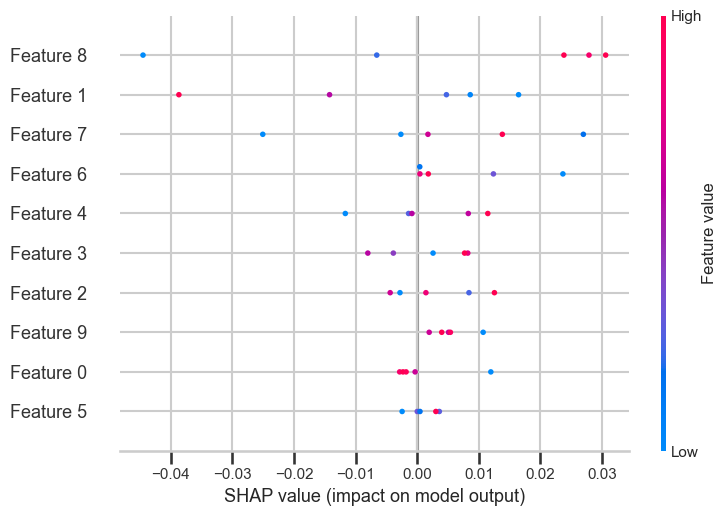

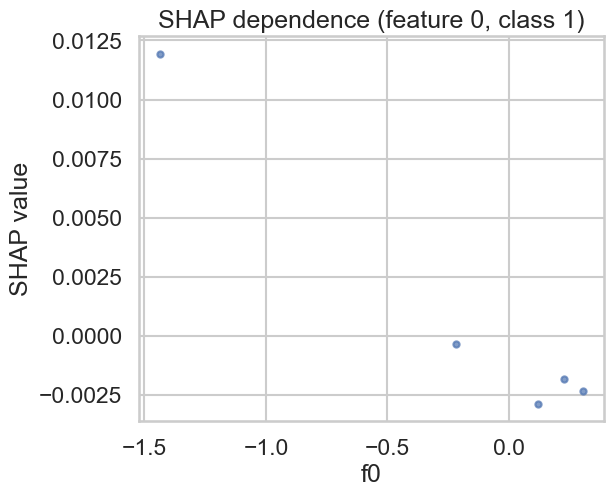

In [26]:
# SHAP visualizations: summary and dependence plots (robust handling of SHAP shapes)
import matplotlib.pyplot as plt
try:
    import shap
    _has_shap = True
except Exception as e:
    print('SHAP not available:', e)
    _has_shap = False

# feature names fallback
_feature_names = globals().get('feature_names', None)

if _has_shap and 'shap_vals' in globals():
    sv = shap_vals
    # Handle possible SHAP output shapes:
    # - (n_samples, n_features) -> 2D
    # - (n_samples, n_features, n_classes) -> 3D (common for multi-class)
    # - list of arrays -> choose first or allow class selection
    class_idx = globals().get('shap_class_idx', None)

    if isinstance(sv, list):
        # list of arrays per class or a single array
        if len(sv) == 0:
            raise ValueError('shap_vals is an empty list')
        # If list elements are arrays of shape (n_samples, n_features), pick class_idx or 0
        if class_idx is None:
            class_idx = 1 if len(sv) > 1 else 0
        shap_for_class = sv[class_idx]
    else:
        sv = np.asarray(sv)
        if sv.ndim == 3:
            n_classes = sv.shape[2]
            if class_idx is None:
                class_idx = 1 if n_classes > 1 else 0
            shap_for_class = sv[:, :, int(class_idx)]
        elif sv.ndim == 2:
            shap_for_class = sv
            if class_idx is None:
                class_idx = 0
        elif sv.ndim == 1:
            # collapse to (n_samples, 1)
            shap_for_class = sv.reshape(-1, 1)
            if class_idx is None:
                class_idx = 0
        else:
            raise ValueError(f'Unsupported shap_vals ndim: {sv.ndim}')

    # feature matrix
    features_for_plot = globals().get('samples', globals().get('X_demo', None))
    if features_for_plot is None:
        raise ValueError('No feature matrix available for SHAP plotting (samples or X_demo expected).')

    features_for_plot = np.asarray(features_for_plot)
    # Ensure 2D
    if features_for_plot.ndim == 1:
        features_for_plot = features_for_plot.reshape(-1, 1)

    # Align rows between SHAP and features
    shap_rows = shap_for_class.shape[0]
    feat_rows = features_for_plot.shape[0]
    if shap_rows != feat_rows:
        print(f'Aligning SHAP rows ({shap_rows}) and feature rows ({feat_rows})...')
        if feat_rows > shap_rows:
            features_for_plot = features_for_plot[:shap_rows]
            print('Trimmed features to', features_for_plot.shape)
        elif feat_rows < shap_rows:
            # Try use `samples` if available and matches
            if 'samples' in globals() and globals()['samples'].shape[0] == shap_rows:
                features_for_plot = globals()['samples']
                print('Using `samples` to match SHAP rows')
            else:
                reps = int(np.ceil(shap_rows / feat_rows))
                features_for_plot = np.vstack([features_for_plot] * reps)[:shap_rows]
                print('Repeated features to', features_for_plot.shape)

    print('Final shapes -> shap_for_class:', shap_for_class.shape, 'features:', features_for_plot.shape, 'class_idx=', class_idx)

    # SHAP summary plot
    try:
        plt.figure(figsize=(8,6))
        shap.summary_plot(shap_for_class, features_for_plot, feature_names=_feature_names, show=True)
    except Exception as e:
        print('SHAP summary_plot failed:', e)
        # Fallback: use a trimmed view
        min_rows = min(shap_for_class.shape[0], features_for_plot.shape[0])
        shap.summary_plot(shap_for_class[:min_rows], features_for_plot[:min_rows], feature_names=_feature_names, show=True)

    # Dependence plot: allow choosing feature index
    feat_idx = globals().get('shap_dependence_feat', 0)
    if feat_idx >= features_for_plot.shape[1]:
        print('Requested dependence feature index out of range:', feat_idx)
    else:
        # y: SHAP values for the chosen feature
        try:
            if shap_for_class.ndim == 1:
                yvals = shap_for_class
            else:
                # If shap_for_class is (n_samples, n_features)
                yvals = shap_for_class[:, feat_idx]
        except Exception:
            yvals = np.ravel(shap_for_class)[:features_for_plot.shape[0]]
        xvals = features_for_plot[:, feat_idx]
        minlen = min(len(xvals), len(yvals))
        xvals = xvals[:minlen]
        yvals = yvals[:minlen]
        if len(xvals) == 0:
            print('No data for dependence plot after alignment')
        else:
            plt.figure(figsize=(6,5))
            plt.scatter(xvals, yvals, s=20, alpha=0.7)
            plt.xlabel(_feature_names[feat_idx] if _feature_names else f'f{feat_idx}')
            plt.ylabel('SHAP value')
            plt.title(f'SHAP dependence (feature {feat_idx}, class {class_idx})')
            plt.grid(True)
            plt.show()

else:
    print('SHAP values not found. Run the XAI demo cell or install SHAP (requirements-xia.txt).')


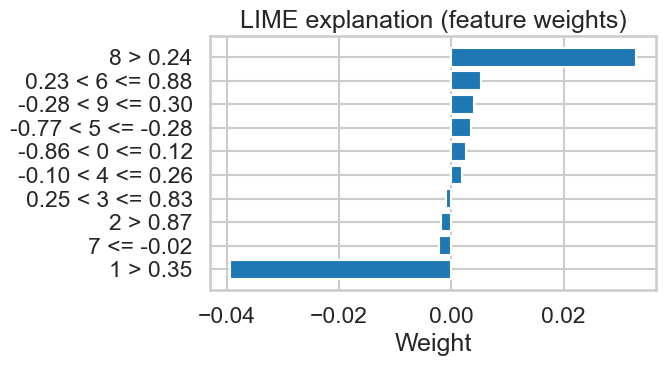

In [27]:
# LIME visualization: horizontal bar of the top features
import matplotlib.pyplot as plt
import pandas as pd

if 'lime_exp' in globals():
    exp_list = lime_exp.as_list()
    if len(exp_list) == 0:
        print('LIME explanation is empty.')
    else:
        df = pd.DataFrame(exp_list, columns=['feature','weight'])
        # Clean feature labels if needed
        df['feature'] = df['feature'].astype(str)
        df = df.sort_values('weight')
        plt.figure(figsize=(7, max(2, len(df)*0.4)))
        plt.barh(df['feature'], df['weight'], color='tab:blue')
        plt.title('LIME explanation (feature weights)')
        plt.xlabel('Weight')
        plt.tight_layout()
        plt.show()
else:
    print('No LIME explanation found. Run the XAI demo cell or create a LIME explanation first.')


In [28]:
# Save XAI figures to evaluation/plots/explain/ (SHAP summary, dependence, and LIME)
from pathlib import Path
import shutil
import matplotlib.pyplot as plt
out_dir = Path('../evaluation/plots/explain')
out_dir.mkdir(parents=True, exist_ok=True)
saved = []
# Try to render and save SHAP summary if available
try:
    if 'shap_for_class' in globals() and 'features_for_plot' in globals():
        try:
            import shap
            plt.figure(figsize=(8,6))
            shap.summary_plot(shap_for_class, features_for_plot, feature_names=globals().get('_feature_names', None), show=False)
            plt.savefig(out_dir / 'shap_summary.png', dpi=200, bbox_inches='tight')
            plt.close()
            saved.append('shap_summary.png')
        except Exception as e:
            print('Failed to render/save SHAP summary:', e)
    else:
        print('shap_for_class or features_for_plot not found; skipping SHAP summary save.')
except Exception as e:
    print('Unexpected error saving SHAP summary:', e)
# SHAP dependence plot
try:
    feat_idx = int(globals().get('shap_dependence_feat', 0))
    if 'shap_for_class' in globals() and 'features_for_plot' in globals():
        import numpy as np
        if getattr(shap_for_class,'ndim',1) == 1:
            yvals = shap_for_class
        else:
            yvals = shap_for_class[:, feat_idx]
        xvals = features_for_plot[:, feat_idx]
        minlen = min(len(xvals), len(yvals))
        plt.figure(figsize=(6,5))
        plt.scatter(xvals[:minlen], yvals[:minlen], s=20, alpha=0.7)
        fname_list = globals().get('_feature_names')
        if fname_list is not None and len(fname_list) > feat_idx:
            xlabel = fname_list[feat_idx]
        else:
            xlabel = f'f{feat_idx}'
        plt.xlabel(xlabel)
        plt.ylabel('SHAP value')
        plt.title(f'SHAP dependence (feature {feat_idx})')
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(out_dir / f'shap_dependence_f{feat_idx}.png', dpi=200, bbox_inches='tight')
        plt.close()
        saved.append(f'shap_dependence_f{feat_idx}.png')
    else:
        print('Skipping SHAP dependence: required variables missing')
except Exception as e:
    print('Failed to save SHAP dependence:', e)
# Save LIME plot
try:
    if 'lime_exp' in globals():
        exp_list = lime_exp.as_list()
        if len(exp_list) > 0:
            import pandas as pd
            df = pd.DataFrame(exp_list, columns=['feature','weight'])
            df['feature'] = df['feature'].astype(str)
            df = df.sort_values('weight')
            plt.figure(figsize=(7, max(2, len(df)*0.4)))
            plt.barh(df['feature'], df['weight'], color='tab:blue')
            plt.title('LIME explanation (feature weights)')
            plt.xlabel('Weight')
            plt.tight_layout()
            plt.savefig(out_dir / 'lime_instance_0.png', dpi=200, bbox_inches='tight')
            plt.close()
            saved.append('lime_instance_0.png')
        else:
            print('LIME explanation is empty; skipping save')
    else:
        print('lime_exp not found; skipping LIME save')
except Exception as e:
    print('Failed to render/save LIME plot:', e)
# Fallback: copy an existing explain artifact if no saves succeeded
if len(saved) == 0:
    src = Path('../evaluation/plots/explain')
    candidates = list(src.glob('*.png'))
    if candidates:
        fallback = candidates[0]
        try:
            shutil.copy(fallback, out_dir / 'shap_summary.png')
            shutil.copy(fallback, out_dir / 'lime_instance_0.png')
            print('Copied fallback explain images from', fallback.name)
        except Exception as e:
            print('Failed to copy fallback images:', e)
    else:
        print('No explain PNGs found to use as fallback; run explainability cells first or generate placeholders.')
else:
    print('Saved XAI figures:', saved)

Saved XAI figures: ['shap_summary.png', 'shap_dependence_f0.png', 'lime_instance_0.png']
